# Documentation
**Author:** Spencer Ressel

**Created:** August 16th, 2024

***

This notebook analyzes aqua-planet simulation data from the CAM6 model run by Mu-Ting Chien. 
Specifically, MJO diagnostics are computed following the specifications listed by the CLIVAR Madden-Julian Oscillation Working Group (MJOWG).
For details, see https://atmos.uw.edu/~daehyun/mjo_diagnostics/

***

# Imports

In [2]:
%load_ext autoreload
%autoreload 2

# Aquaplanet analysis config file
import config
import coords

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

logger.info("Loading Imports...")
# File management
import glob
import os
import sys
from datetime import datetime, timedelta
import copy
import cftime

# Data anaylsis
import numpy as np
import scipy
import xarray as xr
import xeofs as xe
xr.set_options(keep_attrs=True)
import scipy.signal as signal
from scipy.stats import t

# Plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from cartopy import util as cutil
from plotting_utils import get_plotting_attributes
plt.rcParams['mathtext.fontset'] = 'dejavusans'
import string

# Auxiliary functions
sys.path.insert(0, "/glade/u/home/sressel/thesis-work/python/auxiliary_functions/")
from load_aquaplanet_data import load_multi_experiment_processed_data
from auxiliary_functions.xarray_utils import standardize_data, xarray_histogram
from auxiliary_functions.plotting_utils import bmh_colors, tick_labeller, set_plot_mode, get_figsize

logger.info("Imports loaded")

2026-04-20 17:43:34,055 [INFO] Loading Imports...
2026-04-20 17:43:34,064 [INFO] Imports loaded


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [40]:
variables_to_load = [
    "Precipitation",
    # "Outgoing Longwave Radiation",
    # "Zonal Wind",
    # "Meridional Wind",
    "Vertical Wind",
    # "Divergence",
    "Temperature",
    # "Moisture",
    # "Relative Humidity",
    # "Geopotential Height",
    # "Longwave Heating Rate",
    # "Shortwave Heating Rate",
    # "Latent Heat Flux",
    # "Sensible Heat Flux",
    # "Surface Pressure",
    "Moist Static Energy",
    "Dry Static Energy",
    # "Column Moist Static Energy",
    # "Column Water Vapor",
    # "Column Temperature",
    # "Column Longwave Heating",
    # "Column Shortwave Heating",
    # "Potential Temperature",
    # "Saturation Specific Humidity"
    # "Column Relative Humidity",
    # "Diabatic Heating",
    # "Chikira alpha"
    # "Surface Longwave Flux",
    # "Surface Shortwave Flux",
    # "TOA Longwave Flux",
    # "TOA Shortwave Flux",
    # "Net Longwave Flux",
    # "Net Shortwave Flux",
    # "Cloud Ice Water Content",
    # "Cloud Liquid Water Content",
    # "Cloud Fraction"
]

# Load pre-processed data

## Subset data

In [41]:
# Check if the subset has already been loaded
if not 'multi_experiment_variables_subset' in locals():
    # If not loaded yet, load the multi-experiment data with variables subset
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset'
    )
else:
    # If already loaded, reload the data while preserving the existing subset
    # and pass False to prevent overwriting
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset',
        multi_experiment_variables_subset,
        False
    )

2026-04-17 18:19:38,694 [INFO] Loading subset data
2026-04-17 18:19:38,695 [INFO] (1/5) Precipitation...
2026-04-17 18:19:38,696 [INFO] (2/5) Vertical Wind...
2026-04-17 18:19:38,697 [INFO] (3/5) Temperature...
2026-04-17 18:19:38,698 [INFO]     Experiment: -4K...
2026-04-17 18:19:38,816 [INFO]     Experiment: 0K...
2026-04-17 18:19:38,904 [INFO]     Experiment: 4K...
2026-04-17 18:21:35,400 [INFO] (4/5) Moist Static Energy...
2026-04-17 18:21:35,402 [INFO] (5/5) Dry Static Energy...
2026-04-17 18:21:35,403 [INFO] Finished


## Detrended data

In [ ]:
if not 'multi_experiment_variables_detrended' in locals():
    multi_experiment_variables_detrended = load_multi_experiment_processed_data(
        variables_to_load,
        'detrended'
    )
else:
    multi_experiment_variables_detrended = load_multi_experiment_processed_data(
        variables_to_load,
        'detrended',
        multi_experiment_variables_detrended,
        False
    )

## Filtered data

In [13]:
if not 'multi_experiment_variables_filtered' in locals():
    multi_experiment_variables_filtered = load_multi_experiment_processed_data(
        # variables_to_load,
        ['Precipitation', 'Outgoing Longwave Radiation', 'Vertical Wind'],
        # ['Vertical Wind'],
        'filtered'
    )
else:
    multi_experiment_variables_filtered = load_multi_experiment_processed_data(
        # variables_to_load,
        ['Precipitation', 'Outgoing Longwave Radiation', 'Vertical Wind'],
        # ['Vertical Wind'],
        'filtered',
        multi_experiment_variables_filtered,
        False
    )

2026-04-17 18:02:36,604 [INFO] Loading filtered data
2026-04-17 18:02:36,605 [INFO] (1/3) Precipitation...
2026-04-17 18:02:36,606 [INFO]     Experiment: -4K...
2026-04-17 18:02:36,723 [INFO]     Experiment: 0K...
2026-04-17 18:02:36,771 [INFO]     Experiment: 4K...
2026-04-17 18:02:37,496 [INFO] (2/3) Outgoing Longwave Radiation...
2026-04-17 18:02:37,497 [INFO]     Experiment: -4K...
2026-04-17 18:02:37,563 [INFO]     Experiment: 0K...
2026-04-17 18:02:37,605 [INFO]     Experiment: 4K...
2026-04-17 18:02:38,370 [INFO] (3/3) Vertical Wind...
2026-04-17 18:02:38,371 [INFO]     Experiment: -4K...
2026-04-17 18:02:38,421 [INFO]     Experiment: 0K...
2026-04-17 18:02:38,469 [INFO]     Experiment: 4K...
2026-04-17 18:02:53,694 [INFO] Finished


## MJO-filtered

In [ ]:
if not 'multi_experiment_variables_mjo_filtered' in locals():
    multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
        variables_to_load,
        # ['Precipitation', 'Outgoing Longwave Radiation', 'Column Longwave Heating', 'Column Shortwave Heating'],
        'mjo_filtered'
    )
else:
    multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
        variables_to_load,
        # ['Precipitation', 'Outgoing Longwave Radiation', 'Column Longwave Heating', 'Column Shortwave Heating'],
        'mjo_filtered',
        multi_experiment_variables_mjo_filtered,
        False
    )

## Rossby-filtered

In [ ]:
if not 'multi_experiment_variables_rossby_filtered' in locals():
    multi_experiment_variables_rossby_filtered = load_multi_experiment_processed_data(
        variables_to_load,
        'rossby_filtered'
    )
else:
    multi_experiment_variables_rossby_filtered = load_multi_experiment_processed_data(
        variables_to_load,
        'rossby_filtered',
        multi_experiment_variables_rossby_filtered,
        False
    )

## Kelvin-filtered

In [ ]:
if not 'multi_experiment_variables_kelvin_filtered' in locals():
    multi_experiment_variables_kelvin_filtered = load_multi_experiment_processed_data(
        variables_to_load,
        'kelvin_filtered'
    )
else:
    multi_experiment_variables_kelvin_filtered = load_multi_experiment_processed_data(
        variables_to_load,
        'kelvin_filtered',
        multi_experiment_variables_kelvin_filtered,
        False
    )

## Regressed data

In [ ]:
print(f"{f'Loading regressed data':^{config.SEP_WIDTH}}")
# print(f"{'='*config.SEP_WIDTH}")
reference_variable = 'PRCP'
regression_wave_type = 'MJO'

reload_regressed = False
variable_data_by_experiment = {}
if not 'multi_experiment_variables_regressed' in globals() or reload_regressed:
    multi_experiment_variables_regressed = {}
if not 'multi_experiment_significant_indices' in globals() or reload_regressed:
    multi_experiment_significant_indices = {}

for index, variable_name in enumerate(variables_to_load):
    # Print the variable name
    print(f"{'='*config.SEP_WIDTH}")
    print(f"{f'({index+1}/{len(variables_to_load)}) {variable_name}...':<{config.SEP_WIDTH}}")
    print(f"{'-'*config.SEP_WIDTH}")

    # For each variable, loop over the experiments and find/load the data
    print("Loading data...")
    file_location = rf"/glade/campaign/univ/uwas0152/post_processed_data/multi_experiment_variables_regressed"
    regressed_files = glob.glob(
        f"{file_location}/multi_experiment_{variable_name.lower().replace(' ', '_')}"
        + f"_{regression_wave_type}-{reference_variable}.nc"
    )

    # Does the variable have data?
    if regressed_files:
        # Append it to the list
        for index, file in enumerate(regressed_files):
            regression_data = xr.open_dataset(file)
            print(f"{f'    Coefficients...':<{config.SEP_WIDTH-1}}", end="")
            multi_experiment_variables_regressed[variable_name] = regression_data[f"{variable_name} - Coefficients"]
            multi_experiment_variables_regressed[variable_name].name = variable_name
            print(rf"{'✔':>1}")

            print(f"{f'    Significant Indices...':<{config.SEP_WIDTH-1}}", end="")
            multi_experiment_significant_indices[variable_name] = regression_data[f"{variable_name} - Significance"]
            multi_experiment_significant_indices[variable_name].name = variable_name
            print(rf"{'✔':>1}")

    else:
        # Move on to the next variable
        print(rf"{'✘':>1}")
        print(f"    No data")

print(f"{'='*config.SEP_WIDTH}")
print("Finished")

# Mean State Plots

## Calculate mean-state vertical profiles

In [35]:
def calculate_experiment_mean_vertical_profiles(variable, lat_bounds=(-15, 15)):
    return variable.sel(lat=slice(*lat_bounds)).mean(dim=['lat', 'lon', 'time'])

# experiment_mean_temperature = calculate_experiment_mean_vertical_profiles(multi_experiment_variables_subset['Temperature'])
# experiment_mean_moisture = calculate_experiment_mean_vertical_profiles(multi_experiment_variables_subset['Moisture'])
experiment_mean_DSE = calculate_experiment_mean_vertical_profiles(multi_experiment_variables_subset['Dry Static Energy'])
experiment_mean_MSE = calculate_experiment_mean_vertical_profiles(multi_experiment_variables_subset['Moist Static Energy'])
# experiment_mean_divergence = calculate_experiment_mean_vertical_profiles(multi_experiment_variables_subset['Divergence'])
# experiment_mean_omega = calculate_experiment_mean_vertical_profiles(multi_experiment_variables_subset['Vertical Wind'])

## Calculate vertical EOF of vertical wind

In [14]:
recalculate_EOFs = False

multi_experiment_EOF = {}
multi_experiment_explained_variance = {}

logger.info("Computing EOFs")
logger.info('=' * config.SEP_WIDTH)

for variable_name in ['Vertical Wind']:

    logger.info(f"{variable_name}...")
    components = {}
    explained_variance_ratio = {}
    for experiment in coords.experiments.values:
        model = xe.single.EOF()
        model.fit(multi_experiment_variables_filtered[variable_name].sel(
            experiment=experiment,
            lat=slice(-15, 15),
            plev=slice(100, 950)
        ),
        
        dim=['time', 'lat', 'lon']
    )
        components[experiment] = model.components()
        explained_variance_ratio[experiment] = model.explained_variance_ratio()

    multi_experiment_EOF[variable_name] = xr.concat(
        [components[experiment] for experiment in coords.experiments.values],
        dim=coords.experiments,
    )
    multi_experiment_EOF[variable_name].name = 'EOFs'

    multi_experiment_explained_variance[variable_name] = xr.concat(
        [explained_variance_ratio[experiment] for experiment in coords.experiments.values],
        dim=coords.experiments,
    )
    multi_experiment_explained_variance[variable_name].name = 'Explained Variance'

logger.info('=' * config.SEP_WIDTH)
logger.info("Finished")

Computing EOFs
Vertical Wind...                       ✔
Finished


## Latitude-Longitude

Precipitation


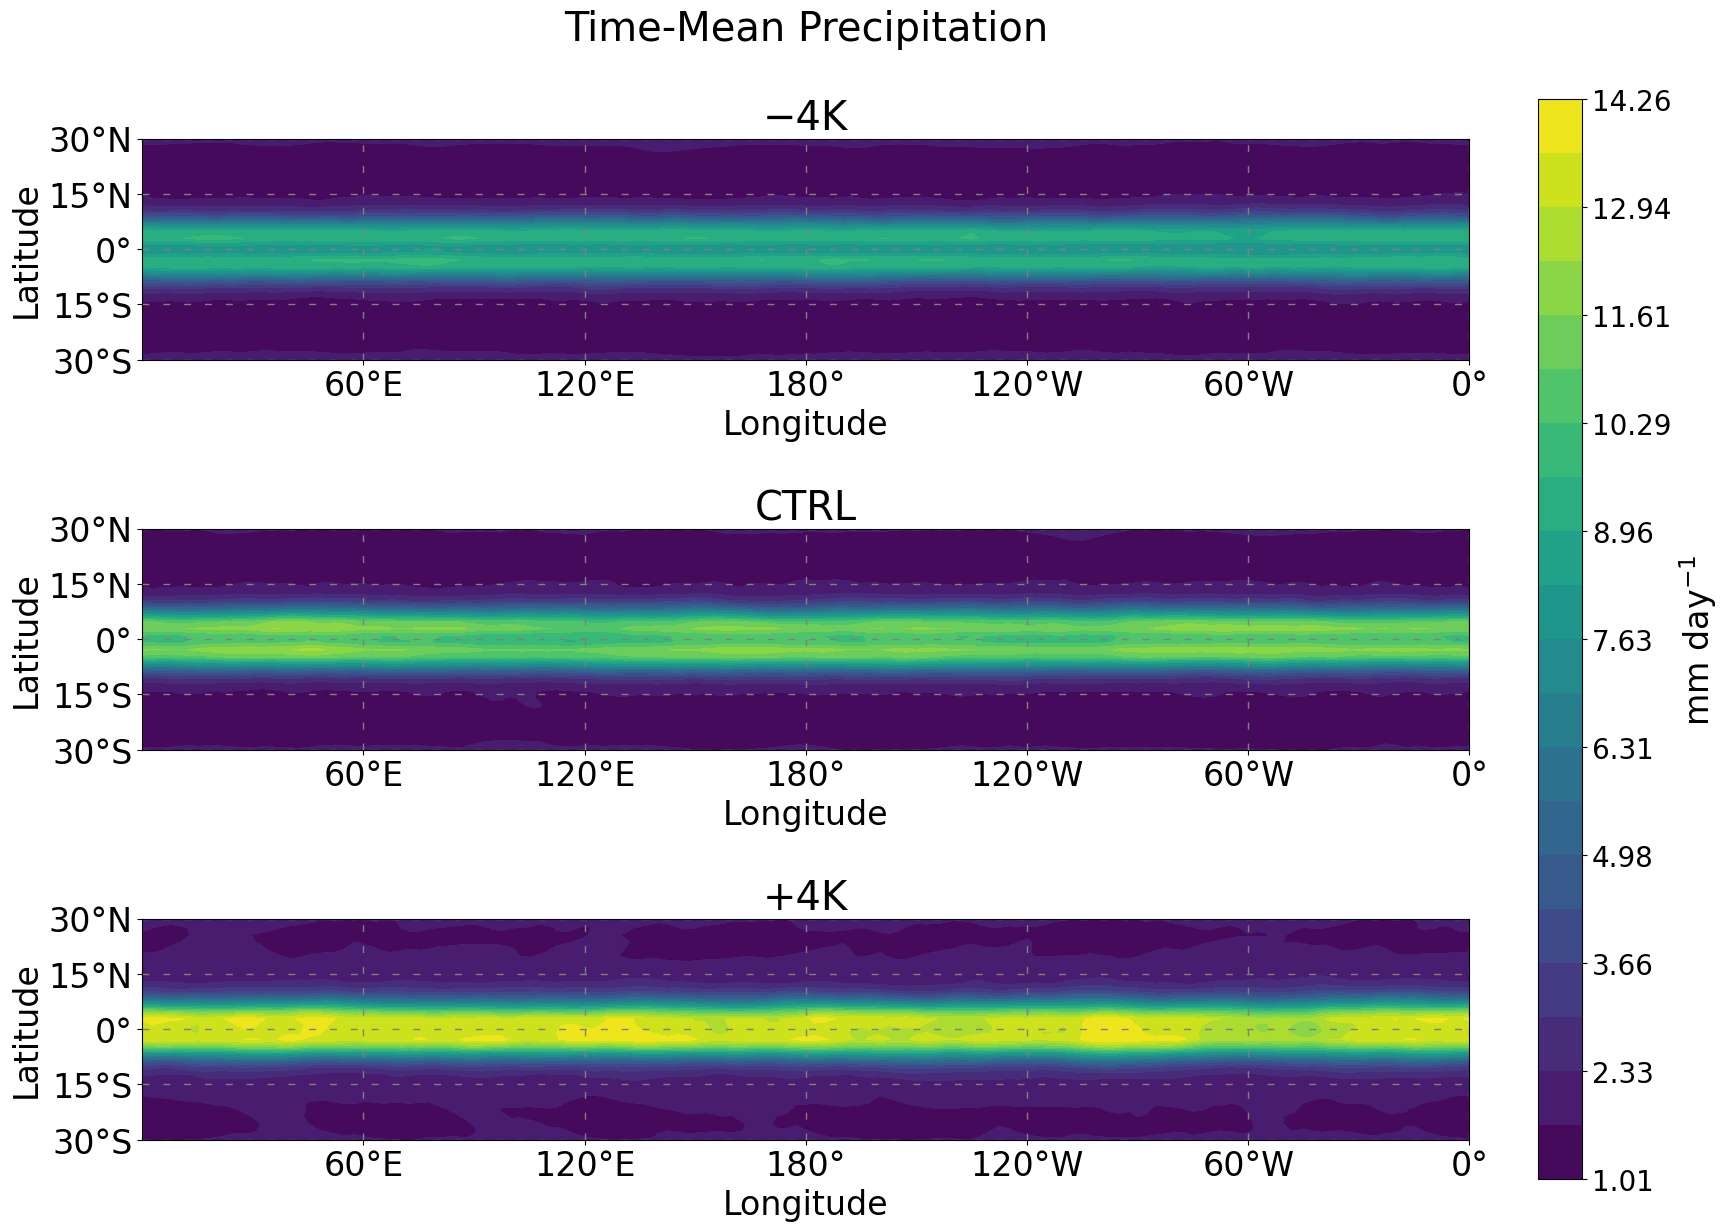

In [30]:
SAVE_FIG=False
plt.style.use("default")
plt.rcParams.update({"font.size": 24})

variables_to_plot = [
    multi_experiment_variables_subset['Precipitation'],
    # multi_experiment_variables_subset['Column Water Vapor'],
    # multi_experiment_variables_subset['Outgoing Longwave Radiation'],
    # multi_experiment_variables_subset['Zonal Wind'].sel(plev=200),
    # multi_experiment_variables_subset['Zonal Wind'].sel(plev=850),
    # multi_experiment_variables_subset['Geopotential Height'].sel(plev=200),
    # multi_experiment_variables_subset['Geopotential Height'].sel(plev=850),
    # multi_experiment_variables_subset['Vertical Wind'].sel(plev=500),
    # multi_experiment_variables_subset['Moist Static Energy'].sel(plev=200),
    # multi_experiment_variables_subset['Moist Static Energy'].sel(plev=850),
    # multi_experiment_variables_subset['Column Temperature'],
    # multi_experiment_variables_subset['Column Water Vapor'],
    # multi_experiment_variables_subset['Column Longwave Heating'],
    # multi_experiment_variables_subset['Column Shortwave Heating'],
    # multi_experiment_variables_subset['Latent Heat Flux'],
    # multi_experiment_variables_subset['Sensible Heat Flux'],
    # multi_experiment_variables_subset['Surface Longwave Flux'],
    # multi_experiment_variables_subset['Surface Shortwave Flux'],
    # multi_experiment_variables_subset['TOA Longwave Flux'],
    # multi_experiment_variables_subset['TOA Shortwave Flux'],
    # multi_experiment_variables_subset['Net Longwave Flux'],
    # multi_experiment_variables_subset['Net Shortwave Flux'],
]

for variable_data in variables_to_plot:
    multi_experiment_lat_lon(
        variable_data.mean(dim='time', keep_attrs=True),
        fig_title = (
            f"Time-Mean"
              + f"{(' ' + (str(variable_data.plev.values) + '-hPa') if 'plev' in variable_data.coords else '')}"
              + f" {variable_data.name}"
        ),
    # size=(16,9),
    filename = f"/glade/u/home/sressel/aquaplanet_analysis/output/mean-state/latitude-longitude/multi-experiment_time-mean_{variable_data.attrs['file_id']}.png",
    savefig=False,
    cmap='variable',
    # norm=('zero-centered' if variable_data.name == 'Zonal Wind' or variable_data.name == 'Vertical Wind' else 'variable')
    )

2026-04-17 18:18:50,951 [INFO] Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//mean-state
2026-04-17 18:18:50,952 [INFO] Output filename: Mean State Vertical Profile of MSE & Divergence
2026-04-17 18:18:50,953 [INFO] Not saving


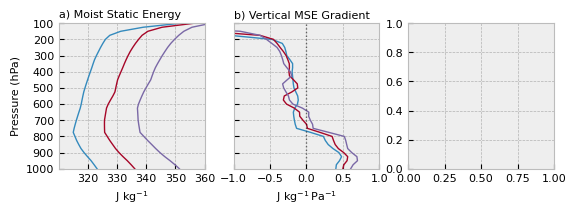

In [38]:
SAVE_FIG = False
PLOT_MODE = "publication"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(1, 3, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.2)

ax = [
    fig.add_subplot(gs[0]),
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2]),
]

legend_lines = [
    Line2D([0], [0], color=bmh_colors(1), lw=2),
    Line2D([0], [0], color=bmh_colors(2), lw=2),
    Line2D([0], [0], color=bmh_colors(3), lw=2)
]

ax[0].set_title(format_title("a) Moist Static Energy", PLOT_MODE, FIG_LAYOUT), loc='left')
# ax[0].set_title("a) Moist Static Energy", loc='left')
MSE_plot = (1e-3*experiment_mean_MSE).plot(ax=ax[0], y='plev', yincrease=False, hue='experiment', add_legend=False)

ax[0].set_ylim(1000, 100)
ax[0].set_xlim(310, 360)
ax[0].set_xlabel(r"J $\text{kg}^{-1}$")
ax[0].set_ylabel('Pressure (hPa)')
ax[0].set_yticks(np.arange(100,1100,100))
ax[0].xaxis.set_major_locator(mticker.MaxNLocator(6, prune="lower"))

# ax[1].set_title("b) Vertical MSE Gradient", loc='left')
ax[1].set_title(format_title("b) Vertical MSE Gradient", PLOT_MODE, FIG_LAYOUT), loc='left')
MSE_grad_plot = (1e-2*experiment_mean_MSE.differentiate('plev')).plot(ax=ax[1], y='plev', yincrease=False, hue='experiment', add_legend=False)
ax[1].axvline(x=0, ls=':', color='k', alpha=0.5)
ax[1].set_ylim(1000, 100)
ax[1].set_xlim(-1, 1)
ax[1].set_xlabel(r"J $\text{kg}^{-1} \, \text{Pa}^{-1}$")
ax[1].set_ylabel('')
ax[1].set_yticks(np.arange(100,1000,100), labels=[])

# # ax[2].set_title("c) Divergence", loc='left')
# ax[2].set_title(format_title("c) Divergence", PLOT_MODE, FIG_LAYOUT), loc='left')
# div_plot = (experiment_mean_divergence).plot(ax=ax[2], y='plev', yincrease=False, hue='experiment', add_legend=False)
# ax[2].axvline(x=0, ls=':', color='k', alpha=0.5)
# ax[2].set_ylim(1000, 100)
# ax[2].set_xlim(-2.5e-6, 1.75e-6)
# ax[2].set_xlabel(r"$\text{s}^{-1}$")
# ax[2].set_ylabel('')
# ax[2].set_yticks(np.arange(100,1000,100), labels=[])

# ax[2].legend(
#     legend_lines,
#     [f"{config.EXPERIMENT_DISPLAY_NAMES[experiment]}" for experiment in coords.experiments.values],
#     loc='upper left',
# )

for axis in ax:
    axis.set_aspect(np.abs((axis.get_xlim()[1] - axis.get_xlim()[0])/(axis.get_ylim()[1] - axis.get_ylim()[0])))

output_filename = 'Mean State Vertical Profile of MSE & Divergence'
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/mean-state")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{str_width-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/mean-state/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

In [ ]:
vertical_omega_gradient = (-1e-2*experiment_mean_omega.differentiate('plev')).sel(plev=slice(200,925))

sign = xr.apply_ufunc(np.sign, vertical_omega_gradient)

# True where sign changes between adjacent levels
sign_change = sign.diff("plev") != 0

transition_plev = sign_change.idxmax("plev")
transition_plev

plev = vertical_omega_gradient["plev"].sel(plev=slice(200,925))

lower_mask = plev >= transition_plev
upper_mask = plev < transition_plev

# lower_int = vertical_omega_gradient.where(lower_mask, 0).integrate("plev")
# upper_int = vertical_omega_gradient.where(upper_mask, 0).integrate("plev")

(1e-2*experiment_mean_MSE.differentiate('plev')).where(upper_mask).mean(dim='plev', skipna=True)
# (-1e-2*experiment_mean_omega.differentiate('plev')).where(upper_mask).mean(dim='plev', skipna=True)

vertical_MSE_gradient = experiment_mean_omega*experiment_mean_MSE.differentiate('plev').sel(plev=slice(200,950))

sign = xr.apply_ufunc(np.sign, vertical_MSE_gradient)

# True where sign changes between adjacent levels
sign_change = sign.diff("plev") != 0

transition_plev = sign_change.idxmax("plev")

plev = vertical_MSE_gradient["plev"].sel(plev=slice(200,950))

lower_mask = plev >= transition_plev
upper_mask = plev < transition_plev

lower_int = vertical_MSE_gradient.where(lower_mask, 0).integrate("plev")
upper_int = vertical_MSE_gradient.where(upper_mask, 0).integrate("plev")

In [ ]:
print("Export: ", end="")
print([f"{val:0.2f}" for val in upper_int.values])
print("Import: ", end="")
print([f"{val:0.2f}" for val in lower_int.values])
print("Net:    ", end="")
print([f"{val:0.2f}" for val in (lower_int + upper_int).values])

In [ ]:
if 'zonal_mean_time_mean_temperature' not in locals():
    zonal_mean_time_mean_temperature = multi_experiment_variables_subset['Temperature'].mean(dim=['time', 'lon'])

plt.style.use('bmh')
plt.rcParams.update({'font.size':16})

fig = plt.figure(figsize=(16, 6))
gs = GridSpec(2, 3, height_ratios=[35, 1], width_ratios=[1, 1, 1], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.01, wspace=0.35)

axes = []
axes.append(fig.add_subplot(gs[0,0]))
axes.append(fig.add_subplot(gs[0,1]))
axes.append(fig.add_subplot(gs[0,2]))
cbar_ax = fig.add_subplot(gs[1, :])

axes[0].set_title("a) 0K - (-4K)", fontsize=16, pad=10)
im = axes[0].contourf(
    zonal_mean_time_mean_temperature.lat,
    zonal_mean_time_mean_temperature.plev,
    (zonal_mean_time_mean_temperature.sel(experiment='0K') - zonal_mean_time_mean_temperature.sel(experiment='-4K')).T,
    # cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05),
    cmap='YlOrRd',
    # norm=mcolors.CenteredNorm(vcenter=0),
    levels=np.linspace(2, 18, 21),
    extend='both'
)

axes[1].set_title("b) 4K - (0K)", fontsize=16, pad=10)
axes[1].contourf(
    zonal_mean_time_mean_temperature.lat,
    zonal_mean_time_mean_temperature.plev,
    (zonal_mean_time_mean_temperature.sel(experiment='4K') - zonal_mean_time_mean_temperature.sel(experiment='0K')).T,
    # cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05),
    cmap='YlOrRd',
    # norm=mcolors.CenteredNorm(vcenter=0),
    levels=np.linspace(2, 18, 21),
    extend='both'
)

axes[2].set_title("c) 4K - (-4K)", fontsize=16, pad=10)
axes[2].contourf(
    zonal_mean_time_mean_temperature.lat,
    zonal_mean_time_mean_temperature.plev,
    (zonal_mean_time_mean_temperature.sel(experiment='4K') - zonal_mean_time_mean_temperature.sel(experiment='-4K')).T,
    # cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05),
    cmap='YlOrRd',
    # norm=mcolors.CenteredNorm(vcenter=0),
    levels=np.linspace(2, 18, 21),
    extend='both'
)

cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('K')
cbar.set_ticks(np.arange(2, 20, 2))

for index, axis in enumerate(axes):
    axis.set_xlim(-30,30)
    axis.set_xticks(np.arange(-30,45,15), labels=tick_labeller(np.arange(-30,45,15), 'lat'), fontsize=16)
    # axis.xaxis.set_major_locator(mticker.MaxNLocator(5, prune="lower"))
    axis.set_ylim(100, 1000)
    axis.set_ylabel('hPa', fontsize=16)
    axis.set_yticks(np.arange(100, 1100, 100), labels=np.arange(100, 1100, 100), fontsize=16)
    axis.invert_yaxis()
    axis.set_aspect((60)/(900))
    axis.tick_params(axis='x', which='major', pad=10, length=10, direction='out')
    axis.tick_params(axis='y', which='major', length=10, direction='out')
    for spine in ['left', 'right', 'top', 'bottom']:
        axis.spines[spine].set_color('k')
        axis.spines[spine].set_lw(1.5)
    axis.grid(False)

    cs = axis.contour(
        zonal_mean_time_mean_temperature.lat,
        zonal_mean_time_mean_temperature.plev,
        (zonal_mean_time_mean_temperature.sel(experiment='0K')-273).T,
        colors='k',
        linewidths=1
    )
    cs0 = axis.contour(
        zonal_mean_time_mean_temperature.lat,
        zonal_mean_time_mean_temperature.plev,
        (zonal_mean_time_mean_temperature.sel(experiment='0K')-273).T,
        levels=[0],
        colors='k',
        linewidths=2
    )
    axis.clabel(cs, fontsize=10, colors='k', fmt='%1.0f', inline=True)
    axis.clabel(cs0, fontsize=10, colors='k', fmt='%1.0f', inline=True)


plt.show()

In [ ]:
SAVE_FIG = False
PLOT_MODE = "publication"
FIG_LAYOUT = 'square'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
ax = fig.add_subplot()

ax.set_title(format_title('Zonal-Mean Time-Mean Precipitation', PLOT_MODE, FIG_LAYOUT))
for index, experiment in enumerate(coords.experiments):
    ax.plot(
        multi_experiment_variables_subset['Precipitation'].lat,
        multi_experiment_variables_subset['Precipitation'].sel(experiment=experiment).mean(dim=['time', 'lon']),
        color=bmh_colors(index+1),
        label=f"{experiments_array.sel(experiment=experiment)['name'].item()}"
    )

ax.set_ylabel(r'P (mm day$^{-1}$)')
ax.set_xlim(-30,30)
ax.set_xticks(ticks=np.arange(-30,40,10), labels=tick_labeller(np.arange(-30,40,10), 'lat'))
ax.set_xlabel('Latitude')
ax.legend(loc='upper right')
plt.show()

## Longitude-Height

In [ ]:
variables_to_plot = [
    # multi_experiment_variables_subset['Zonal Wind'],
    # multi_experiment_variables_subset['Meridional Wind'],
    # multi_experiment_variables_subset['Vertical Wind'],
    # multi_experiment_variables_subset['Geopotential Height'],
    # multi_experiment_variables_subset['Moisture'],
    # multi_experiment_variables_subset['Temperature'],
    # multi_experiment_variables_subset['Longwave Heating Rate'],
    # multi_experiment_variables_subset['Shortwave Heating Rate'],
    multi_experiment_variables_subset['Moist Static Energy'],
]

meridional_mean_region = (-10,10)
for variable_data in variables_to_plot:
    multi_experiment_lon_height(
        variable_data.mean(dim='time'),
        fig_title = (
            f"Time-Mean Meridional-Mean"
            + f" ({tick_labeller([meridional_mean_region[0]], 'lat')[0]}"
            + f"-{tick_labeller([meridional_mean_region[1]], 'lat')[0]})"
            + f" {variable_data.name.title()}"
        ),
        meridional_mean_region = slice(*meridional_mean_region)
    )

In [ ]:
data_to_plot = multi_experiment_variables_subset['Chikira alpha'].sel(
    lat=slice(-15,15), plev=slice(100,950)
).mean(dim=['time', 'lat'])

plt.style.use("default")
plt.rcParams.update({"font.size": 24})

fig = plt.figure(figsize=(16, 20))
gs = GridSpec(3, 2, width_ratios=[30, 1], height_ratios=[1, 1, 1], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.1)

axes = []
axes.append(fig.add_subplot(gs[0,0]))
axes.append(fig.add_subplot(gs[1,0]))
axes.append(fig.add_subplot(gs[2,0]))
cb_ax = fig.add_subplot(gs[:, 1])

grand_max = data_to_plot.max()
grand_min = data_to_plot.min()

for ax, experiment in zip(axes, coords.experiments):

    ax.set_title(f"{experiments_array.sel(experiment=experiment)['name'].item()}")

    v_center = 1
    half_range = np.max(np.abs(data_to_plot.sel(experiment=experiment) - v_center))

    # Add cyclic point
    cdata, clon = cutil.add_cyclic_point(
        data_to_plot.sel(experiment=experiment),
        coord=data_to_plot.lon,
    )

    # Plot data
    im = ax.contourf(
        clon,
        data_to_plot.plev,
        cdata,
        levels=np.linspace(-3, 3, 21),
        # levels=21,
        cmap=modified_colormap('coolwarm', 'white', 0.025, 0.025),
        norm=mcolors.CenteredNorm(vcenter=v_center, halfrange=half_range),
        extend='both'
    )

    # Add colorbar
    cbar = fig.colorbar(
        im,
        cax=cb_ax,
        # ticks=np.arange(-3, 5, 2),
        ticks = [1],
        label=data_to_plot.attrs['units'],
        orientation="vertical",
    )
    cbar.ax.tick_params(labelsize=20)

    ax.contour(
        clon,
        data_to_plot.plev,
        cdata,
        levels=[1],
        colors='k',
    )

    # ax.axvline(x=180, ls=':', color='darkgray')

    # Axis parameters
    ax.set_xlim(0, 360)
    x_ticks = np.arange(0, 360 + 60, 60)
    ax.set_xticks(x_ticks)
    # ax.set_xticklabels(tick_labeller(x_ticks, "lon"))
    # ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
    ax.set_xlabel("Longitude")

    ax.set_ylim(100, 950)
    ax.set_yticks(np.arange(100, 1000, 100))
    ax.set_ylabel("Pressure (hPa)")
    ax.invert_yaxis()

    ax.set_aspect('auto')

fig.suptitle(
    "Time-mean near-equatorial mean Chikira alpha",
    x=(axes[0].get_position().x0 + axes[0].get_position().x1)/2,
    ha='center',
    y=1.025
)

plt.show()

In [ ]:
# SAVE_FIG=False
# xr.set_options(keep_attrs=True)
# meridional_mean_region = slice(-10,10)

# variables_to_plot = [
#     multi_experiment_variables_subset['zonal wind'.title()],
#     # multi_experiment_variables_subset['meridional wind'.title()],
#     # multi_experiment_variables_subset['vertical wind'.title()],
#     # multi_experiment_variables_subset['temperature'.title()],
#     # multi_experiment_variables_subset['moisture'.title()],
#     # multi_experiment_variables_subset['geopotential height'.title()],
#     # multi_experiment_variables_subset['moist static energy'.title()],
#     # multi_experiment_variables_subset['longwave heating rate'.title()],
#     # multi_experiment_variables_subset['shortwave heating rate'.title()],
# ]

# for variable_data in variables_to_plot:

#     # variable_data = xr.concat(
#     #         [variable[experiment] for experiment in coords.experiments.values],
#     #         dim=coords.experiments)
#     # variable_data = variable_data.rename({"concat_dim": "experiment"})

#     time_mean_meridional_mean_variable_data = variable_data.sel(
#         lat=meridional_mean_region
#     ).mean(dim=['lat', 'time'])

#     grand_max = time_mean_meridional_mean_variable_data.max()
#     grand_min = time_mean_meridional_mean_variable_data.min()

#     plt.style.use("default")
#     plt.rcParams.update({"font.size": 24})

#     fig = plt.figure(figsize=(16, 16))
#     gs = GridSpec(3, 2, width_ratios=[30, 1], height_ratios=[1, 1, 1], figure=fig)
#     gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.4, wspace=0.1)

#     axes = []
#     axes.append(fig.add_subplot(gs[0,0]))
#     axes.append(fig.add_subplot(gs[1,0]))
#     axes.append(fig.add_subplot(gs[2,0]))
#     cb_ax = fig.add_subplot(gs[:, 1])

#     for ax, experiment in zip(axes, coords.experiments):

#         ax.set_title(
#             (
#                 f"{experiment} Time-Mean Meridional-Mean"
#               + f" ({tick_labeller([meridional_mean_region.start], 'lat')[0]}"
#               + f"-{tick_labeller([meridional_mean_region.stop], 'lat')[0]})"
#               + f" {time_mean_meridional_mean_variable_data.name.title()}"
#             ),
#             pad=15
#         )

#         # Add cyclic point
#         cdata, clon = cutil.add_cyclic_point(
#             time_mean_meridional_mean_variable_data.sel(experiment=experiment).T,
#             coord=time_mean_meridional_mean_variable_data.lon,
#         )

#         # Plot data
#         im = ax.contourf(
#             clon,
#             time_mean_meridional_mean_variable_data.plev,
#             cdata,
#             levels=16,
#             **{k: copy.deepcopy(v) for k, v in {
#                 "norm": plotting_attributes[time_mean_meridional_mean_variable_data.name].get("norm"),
#                 "cmap": plotting_attributes[time_mean_meridional_mean_variable_data.name].get("cmap")
#             }.items() if v is not None}
#         )

#         # Add colorbar
#         cbar = fig.colorbar(
#             im,
#             cax=cb_ax,
#             label=time_mean_meridional_mean_variable_data.attrs['units'],
#             orientation="vertical",
#         )
#         cbar.ax.tick_params(labelsize=20)

#         # Axis parameters
#         ax.set_xlim(0, 360)
#         x_ticks = np.arange(0, 360 + 60, 60)
#         ax.set_xticks(x_ticks)
#         ax.set_xticklabels(tick_labeller(x_ticks-180, "lon"))
#         ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
#         ax.set_xlabel("Longitude")

#         ax.set_ylim(100, 950)
#         ax.set_yticks(np.arange(100, 1000, 100))
#         ax.set_ylabel("Pressure (hPa)")
#         ax.invert_yaxis()

#         ax.set_aspect('auto')

#     if not SAVE_FIG:
#         plt.show()
#     else:
#         save_string = (
#             f"multi-experiment_time-mean_meridional-mean-{tick_labeller([meridional_mean_region.start], 'lat', False)[0]}"
#           + f"-{tick_labeller([meridional_mean_region.stop], 'lat', False)[0]}"
#           + f"_{time_mean_meridional_mean_variable_data.attrs['file_id']}.png"
#             )
#         print(f"Saving plot as {save_string}")
#         plt.savefig(
#             f"{output_directory}/mean-state/longitude-height/{save_string}",
#             dpi=500,
#             bbox_inches="tight",
#         )

# print(f"{'='*40}")
# print("Finished")

## Latitude-Height

In [ ]:
SAVE_FIG=False
xr.set_options(keep_attrs=True)

variables_to_plot = [
    multi_experiment_variables_subset['zonal wind'.title()],
    # multi_experiment_variables_subset['meridional wind'.title()],
    # multi_experiment_variables_subset['vertical wind'.title()],
    # multi_experiment_variables_subset['temperature'.title()],
    # multi_experiment_variables_subset['moisture'.title()],
    # multi_experiment_variables_subset['geopotential height'.title()],
    # multi_experiment_variables_subset['moist static energy'.title()],
    # multi_experiment_variables_subset['longwave heating rate'.title()],
    # multi_experiment_variables_subset['shortwave heating rate'.title()],
]

for variable_data in variables_to_plot:

    time_mean_zonal_mean_variable_data = variable_data.sel(
    ).mean(dim=['lon', 'time'])

    grand_max = time_mean_zonal_mean_variable_data.max()
    grand_min = time_mean_zonal_mean_variable_data.min()

    plt.style.use("default")
    plt.rcParams.update({"font.size": 16})

    fig = plt.figure(figsize=(8, 16))
    gs = GridSpec(3, 2, width_ratios=[30, 1], height_ratios=[1, 1, 1], figure=fig)
    gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.4, wspace=0.1)

    axes = []
    axes.append(fig.add_subplot(gs[0,0]))
    axes.append(fig.add_subplot(gs[1,0]))
    axes.append(fig.add_subplot(gs[2,0]))
    cb_ax = fig.add_subplot(gs[:, 1])

    for ax, experiment in zip(axes, coords.experiments):

        # ax.set_title(
        #     (
        #         f"{experiment} Time-Mean Zonal-Mean"
        #       + f" {time_mean_zonal_mean_variable_data.name.title()}"
        #     ),
        #     pad=15
        # )
        ax.set_title(experiments_array.sel(experiment=experiment)['name'].item())

        # Plot data
        im = ax.contourf(
            time_mean_zonal_mean_variable_data.lat,
            time_mean_zonal_mean_variable_data.plev,
            time_mean_zonal_mean_variable_data.sel(experiment=experiment).T,
            levels=16,
            **{k: copy.deepcopy(v) for k, v in {
                "norm": plotting_attributes[time_mean_zonal_mean_variable_data.name].get("norm"),
                "cmap": plotting_attributes[time_mean_zonal_mean_variable_data.name].get("cmap")
            }.items() if v is not None}
        )

        # Add colorbar
        cbar = fig.colorbar(
            im,
            cax=cb_ax,
            label=time_mean_zonal_mean_variable_data.attrs['units'],
            orientation="vertical",
        )
        cbar.ax.tick_params(labelsize=20)

        # Axis parameters
        ax.set_xlim(-30, 30)
        x_ticks = np.arange(-30, 30+10, 10)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(tick_labeller(x_ticks, "lat"))
        # ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
        ax.set_xlabel("Latitude")

        ax.set_ylim(100, 950)
        ax.set_yticks(np.arange(100, 1000, 100))
        ax.set_ylabel("Pressure (hPa)")
        ax.invert_yaxis()

        # ax.set_aspect('auto')
        ax.set_aspect(60/850)

    fig.suptitle(
        f"Time-Mean Zonal-Mean"
        + f" {variable_data.name.title()}",
        x=(axes[0].get_position().x0 + axes[0].get_position().x1)/2,
        ha='center',
        y=1.005
    )

    if not SAVE_FIG:
        plt.show()
    else:
        save_string = (
            f"multi-experiment_time-mean_zonal-mean"
          + f"_{time_mean_zonal_mean_variable_data.attrs['file_id']}.png"
            )
        print(f"Saving plot as {save_string}")
        plt.savefig(
            f"{output_directory}/mean-state/latitude-height/{save_string}",
            dpi=500,
            bbox_inches="tight",
        )

print(f"{'='*40}")
print("Finished")

### Chikira Alpha

In [ ]:
SAVE_FIG=True

if 'alpha' not in locals():
    exner_function = (multi_experiment_variables_subset['Moisture'].plev/1000)**(DRY_AIR_GAS_CONSTANT/SPECIFIC_HEAT)
    alpha = (
        - (HEAT_OF_VAPORIZATION/SPECIFIC_HEAT/exner_function)
        * (0.01*multi_experiment_variables_subset['Moisture'].differentiate('plev'))
        / (0.01*multi_experiment_variables_subset['Potential Temperature'].differentiate('plev'))
    )

plt.style.use('bmh')
plt.rcParams.update({'font.size':14})
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 3, height_ratios=[30, 1], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.25)

axes_list = []
axes_list.append(fig.add_subplot(gs[0,0]))
axes_list.append(fig.add_subplot(gs[0,1]))
axes_list.append(fig.add_subplot(gs[0,2]))
cbar_axes = fig.add_subplot(gs[-1, :])

for index, (ax, experiment) in enumerate(zip(axes_list, coords.experiments)):
    ax.set_title(f"{string.ascii_letters[index]}) {experiments_array.sel(experiment=experiment)['name'].item()}", loc='left')
    im = ax.contourf(
        alpha.lat,
        alpha.plev.sel(plev=slice(100,950)),
        alpha.sel(plev=slice(100, 950), experiment=experiment).mean(dim=['time', 'lon']),
        levels=np.arange(0, 4.25+0.25, 0.25),
        extend='max',
        norm=mcolors.CenteredNorm(vcenter=1),
        cmap='coolwarm'
        # cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05)
    )
    ax.contour(
        alpha.lat,
        alpha.plev.sel(plev=slice(100,950)),
        alpha.sel(plev=slice(100, 950), experiment=experiment).mean(dim=['time', 'lon']),
        levels=[1],
        linewidths=1,
        colors='k'
    )
    ax.invert_yaxis()
    ax.set_xlim(-30, 30)
    ax.set_xticks(np.arange(-30, 45, 15), labels=tick_labeller(np.arange(-30, 45, 15), 'lat'))
    ax.set_xlabel('Latitude')

    # ax.set_yticks(np.arange(100, 975+100, 100))
    ax.set_ylabel('Pressure (hPa)')

cbar = fig.colorbar(im, cax=cbar_axes, orientation='horizontal')
# cbar.ax.plot([0, 0], [1, 0], 'k')
cbar.ax.axvline(1, c='k')

output_filename = (
    f"Latitude-Height Mean Chikira Alpha"
)
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/mean-state/")
print(f"Output file: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/mean-state/{output_filename}.png",
        dpi=500,
        bbox_inches="tight"
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

## Experiment-mean vertical profiles

In [ ]:
variables_loaded = {}
for exp_index, experiment in enumerate(['-4K', '0K', '4K']):

    print(f"{'-'*config.SEP_WIDTH}")
    print(f"{f'Loading {experiment} data...':<{config.SEP_WIDTH}}")
    print(f"{'-'*config.SEP_WIDTH}")
    variable_data_files = sorted(glob.glob(
        rf"{config.DATA_DIRECTORY}/{experiment}/daily_model-level_data/*.nc"
    ))
    for index, file in enumerate(variable_data_files):
        variable_data = xr.open_dataarray(file)
        print(f"{f'({index+1}/{len(variable_data_files)}) {variable_data.name}...':<{config.SEP_WIDTH-1}}", end="")
        variables_loaded[variable_data.name] = variable_data.sel(time=slice(START_TIME, END_TIME))
        print(rf"{'✔':>1}")
    print(f"{'-'*config.SEP_WIDTH}")

    non_timed_data =  xr.open_dataset(
        rf"/glade/campaign/univ/uwas0114/SST_AQP3_Qobs_27_-4K_3h_10y/atm/hist/SST_AQP3_Qobs_27_-4K_3h_20y_new2.cam.h1.0001-02-16-43200.nc"
    )

    print(f"{'Pressure Array...':<{config.SEP_WIDTH-1}}", end="")
    lower_level_pressure = 1100.*100.
    upper_level_pressure = 100.*100.
    surface_pressure = variables_loaded['PS']
    pressure_array = non_timed_data['hyam']*non_timed_data['P0'] + non_timed_data['hybm']*surface_pressure
    pressure_array = pressure_array.transpose("time", "lev", "lat", "lon")
    print(rf"{'✔':>1}")

    time_mean_temperature = variables_loaded['T'].mean(dim=['time'])
    temperature_minimum_index = time_mean_temperature.argmin('lev')
    temperature_minimum_pressure_level = pressure_array.mean(dim='time').transpose("lev", ...)[temperature_minimum_index].mean(dim=['lat', 'lon'])
    print(temperature_minimum_pressure_level.values)

In [ ]:
variables_loaded = {}
experiment_mean_temperature = {}
vertical_temperature_gradient = {}

non_timed_data =  xr.open_dataset(
    rf"/glade/campaign/univ/uwas0114/SST_AQP3_Qobs_27_-4K_3h_10y/atm/hist/SST_AQP3_Qobs_27_-4K_3h_20y_new2.cam.h1.0001-02-16-43200.nc"
)

for exp_index, experiment in enumerate(coords.experiments):

    print(f"{'-'*config.SEP_WIDTH}")
    print(f"{f'Loading {experiment} data...':<{config.SEP_WIDTH}}")
    print(f"{'-'*config.SEP_WIDTH}")
    variable_data_files = sorted(glob.glob(
        rf"{config.DATA_DIRECTORY}/{experiment}/daily_model-level_data/*.nc"
    ))
    for index, file in enumerate(variable_data_files):
        variable_data = xr.open_dataarray(file)
        print(f"{f'({index+1}/{len(variable_data_files)}) {variable_data.name}...':<{config.SEP_WIDTH-1}}", end="")
        variables_loaded[variable_data.name] = variable_data.sel(time=slice(START_TIME, END_TIME))
        print(rf"{'✔':>1}")

    surface_pressure = variables_loaded['PS']
    pressure_array = non_timed_data['hyam']*non_timed_data['P0'] + non_timed_data['hybm']*surface_pressure
    pressure_array = pressure_array.transpose("time", "lev", "lat", "lon")

    print(np.max(variables_loaded['T']))
    vertical_temperature_gradient[experiment] = xr.zeros_like(variables_loaded['T'])
    vertical_temperature_gradient[experiment][:, 0] = (
        (variables_loaded['T'][:, 1].values - variables_loaded['T'][:, 0].values)
        / (pressure_array[:, 1].values - pressure_array[:, 0].values)
    )
    vertical_temperature_gradient[experiment][:, 1:-1] = (
        (variables_loaded['T'][:, 2:].values - variables_loaded['T'][:, :-2].values)
        / (pressure_array[:, 2:].values - pressure_array[:, :-2].values)
    )
    vertical_temperature_gradient[experiment][:, -1] = (
        (variables_loaded['T'][:, -1].values - variables_loaded['T'][:, -2].values)
        / (pressure_array[:, -1].values - pressure_array[:, -2].values)
    )
    print(f"{'-'*config.SEP_WIDTH}")

multi_experiment_vertical_temperature_gradient = xr.concat(
    [vertical_temperature_gradient[experiment] for experiment in coords.experiments.values],
    dim=experiments_array
)

In [ ]:
variables_loaded = {}
for exp_index, experiment in enumerate(coords.experiments):

    print(f"{'-'*config.SEP_WIDTH}")
    print(f"{f'Loading {experiment} data...':<{config.SEP_WIDTH}}")
    print(f"{'-'*config.SEP_WIDTH}")
    variable_data_files = sorted(glob.glob(
        rf"{config.DATA_DIRECTORY}/{experiment}/daily_model-level_data/*.nc"
    ))
    for index, file in enumerate(variable_data_files):
        variable_data = xr.open_dataarray(file)
        print(f"{f'({index+1}/{len(variable_data_files)}) {variable_data.name}...':<{config.SEP_WIDTH-1}}", end="")
        variables_loaded[variable_data.name] = variable_data.sel(time=slice(START_TIME, END_TIME))
        print(rf"{'✔':>1}")
    print(f"{'-'*config.SEP_WIDTH}")

    recalculate_budgets = True

    non_timed_data =  xr.open_dataset(
        rf"/glade/campaign/univ/uwas0114/SST_AQP3_Qobs_27_-4K_3h_10y/atm/hist/SST_AQP3_Qobs_27_-4K_3h_20y_new2.cam.h1.0001-02-16-43200.nc"
    )

    if recalculate_budgets:
        print(f"{'Pressure Array...':<{config.SEP_WIDTH-1}}", end="")
        lower_level_pressure = 1100.*100.
        upper_level_pressure = 100.*100.
        surface_pressure = variables_loaded['PS']
        pressure_array = non_timed_data['hyam']*non_timed_data['P0'] + non_timed_data['hybm']*surface_pressure
        pressure_array = pressure_array.transpose("time", "lev", "lat", "lon")
        print(rf"{'✔':>1}")

        print(f"{'Moist Static Energy...':<{config.SEP_WIDTH-1}}", end="")
        GRAVITY = 9.8                        #  m/s^2
        SPECIFIC_HEAT = 1005.7               #  J/Kg*K ; specific heat at constant pressure for dry air
        HEAT_OF_VAPORIZATION = 2.501e6       #  [J/kg]=[m2/s2]  Latent Heat of Vaporization at 0
        HEAT_OF_FUSION = 3.337e5             # [J/kg]=[m2/s2]  Latent Heat of Sublimation at 0
        moist_static_energy = (
            HEAT_OF_VAPORIZATION*variables_loaded['Q']
            - HEAT_OF_FUSION*variables_loaded['CLDICE']
            + SPECIFIC_HEAT*variables_loaded['T']
            + GRAVITY*variables_loaded['Z3']
        )

        print(moist_static_energy.max())

### Vertical Profile plotter

In [ ]:
ERA5_temperature = xr.open_dataarray("/glade/campaign/univ/uwas0152/post_processed_data/ERA5_vertical_temperature_profile.nc")
ERA5_moisture = xr.open_dataarray("/glade/campaign/univ/uwas0152/post_processed_data/ERA5_vertical_moisture_profile.nc")

# ERA5_temperature = xr.open_dataarray("/glade/campaign/univ/uwas0152/post_processed_data/test_ERA5_vertical_temperature_profile.nc")
# ERA5_moisture = xr.open_dataarray("/glade/campaign/univ/uwas0152/post_processed_data/test_ERA5_vertical_moisture_profile.nc")

experiment_mean_temperature = multi_experiment_variables_subset['Temperature'].sel(lat=slice(-30,30)).mean(dim=['time', 'lat', 'lon'])
experiment_mean_moisture = multi_experiment_variables_subset['Moisture'].sel(lat=slice(-30,30)).mean(dim=['time', 'lat', 'lon'])
experiment_mean_moisture_gradient = 100*experiment_mean_moisture.differentiate('plev')

In [ ]:
SAVE_FIG = False
PLOT_MODE = "publication"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(2, 3, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.35, wspace=0.1)

axes = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
    fig.add_subplot(gs[1,0]),
    fig.add_subplot(gs[1,1])
]
# axes.append(fig.add_subplot(gs[3]))

# Plot temperature profile
axes[0].set_title(format_title('a) Temperature', PLOT_MODE, FIG_LAYOUT), loc='left')
for index, experiment in enumerate(coords.experiments):
    axes[0].plot(
        experiment_mean_temperature.sel(experiment=experiment),
        experiment_mean_temperature.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color = bmh_colors(index+1),
    )

axes[0].plot(
    ERA5_temperature,
    ERA5_temperature.plev,
    label='ERA5',
    color = 'k',
)
axes[0].set_xlabel('K')
axes[0].set_xticks(np.arange(200, 340, 40))
axes[0].set_ylabel('Pressure (hPa)')
axes[0].axvline(x=273.15, ls='--', color='gray')

# Plot vertical moisture profile
axes[1].set_title(format_title('b) Specific Humidity', PLOT_MODE, FIG_LAYOUT), loc='left')
for index, experiment in enumerate(coords.experiments):
    axes[1].plot(
        1000*experiment_mean_moisture.sel(experiment=experiment),
        experiment_mean_moisture.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color = bmh_colors(index+1),
    )

axes[1].plot(
    1000*ERA5_moisture,
    ERA5_moisture.plev,
    label='ERA5',
    color = 'k',
)

axes[1].set_xlabel(r'g kg$^{-1}$')
axes[1].set_xticks(np.arange(0, 20+5, 5))

# Plot vertical moisture gradient profile
axes[2].set_title(format_title('c) Vertical Specific Humidity Gradient', PLOT_MODE, FIG_LAYOUT), loc='left')
for index, experiment in enumerate(coords.experiments):
    axes[2].plot(
        1000*experiment_mean_moisture.sel(experiment=experiment).differentiate('plev'),
        experiment_mean_moisture.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color = bmh_colors(index+1),
    )

axes[2].plot(
    1000*ERA5_moisture.differentiate('plev'),
    ERA5_moisture.plev,
    label='ERA5',
    color = 'k',
)

axes[2].set_xlabel(fr'g kg$^{{{-1}}}$ hPa$^{{{-1}}}$')
axes[2].yaxis.tick_right()
axes[2].set_xticks(np.arange(0, 0.08, 0.02))

axes[2].legend(loc='upper right')

# Plot inter-experiment temperature differences
axes[3].set_title(format_title('d) Temperature Difference', PLOT_MODE, FIG_LAYOUT), loc='left')
axes[3].plot(
    experiment_mean_temperature.diff('experiment').sel(experiment='4K'),
    experiment_mean_temperature.plev,
    color = bmh_colors(6),
)
axes[3].plot(
    experiment_mean_temperature.diff('experiment').sel(experiment='0K'),
    experiment_mean_temperature.plev,
    color = bmh_colors(4),
)
axes[3].set_xlabel('K')
axes[3].set_ylabel('Pressure (hPa)')

# Plot inter-experiment moisture differences
axes[4].set_title('d) Specific \nHumidity Difference', loc='left')
axes[4].plot(
    1000*experiment_mean_moisture.diff('experiment').sel(experiment='4K'),
    experiment_mean_moisture.plev,
    color = bmh_colors(6),
    label = '−4K → CTRL',
)
axes[4].plot(
    1000*experiment_mean_moisture.diff('experiment').sel(experiment='0K'),
    experiment_mean_moisture.plev,
    color = bmh_colors(4),
    label = 'CTRL → +4K',
)
axes[4].legend(loc='upper right')
axes[4].set_xticks(np.arange(0, 5, 1))
axes[4].set_xlabel(r'g kg$^{-1}$')
axes[4].set_yticklabels('')

# Format axes
for index, ax in enumerate(axes):
    if index != 1 and index != 4:
        ax.set_yticks(np.arange(0, 1100, 100), labels=np.arange(0, 1100, 100))
    else:
        ax.set_yticks(ticks=np.arange(0, 1100, 100), labels=[])
    ax.set_ylim(100, 1000)
    ax.invert_yaxis()

output_filename = "Mean-state Vertical Profiles"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}")
print(f"Output file: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.pdf",
        dpi=500,
        bbox_inches="tight"
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
SAVE_FIG = True
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '16'
plt.rcParams['axes.labelsize'] = '16'
plt.rcParams['xtick.labelsize'] = '14'
plt.rcParams['ytick.labelsize'] = '14'
plt.rcParams['lines.linewidth'] = '2'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(1, 3, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.2)

axes = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
    # fig.add_subplot(gs[1,0]),
    # fig.add_subplot(gs[1,1])
]
# axes.append(fig.add_subplot(gs[3]))

# Plot temperature profile
# axes[0].set_title(format_title('a) Temperature', PLOT_MODE, FIG_LAYOUT), loc='left')
for index, experiment in enumerate(coords.experiments):
    axes[0].plot(
        experiment_mean_temperature.sel(experiment=experiment),
        experiment_mean_temperature.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color = bmh_colors(index+1),
    )

axes[0].plot(
    ERA5_temperature,
    ERA5_temperature.plev,
    label='ERA5',
    color = 'k',
)
axes[0].set_xlabel('T (K)')
axes[0].set_xticks(np.arange(200, 320, 40))
axes[0].set_ylabel('Pressure (hPa)')
axes[0].axvline(x=273.15, ls='--', color='gray')

# Plot vertical moisture profile
# axes[1].set_title(format_title('b) Specific Humidity', PLOT_MODE, FIG_LAYOUT), loc='left')
for index, experiment in enumerate(coords.experiments):
    axes[1].plot(
        1000*experiment_mean_moisture.sel(experiment=experiment),
        experiment_mean_moisture.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color = bmh_colors(index+1),
    )

axes[1].plot(
    1000*ERA5_moisture,
    ERA5_moisture.plev,
    label='ERA5',
    color = 'k',
)

axes[1].set_xlabel(r'q (g kg$^{-1}$)')
axes[1].set_xticks(np.arange(0, 20+5, 5))

# Plot vertical moisture gradient profile
# axes[2].set_title(format_title('c) Vertical Specific Humidity Gradient', PLOT_MODE, FIG_LAYOUT), loc='left')
for index, experiment in enumerate(coords.experiments):
    axes[2].plot(
        1000*experiment_mean_moisture.sel(experiment=experiment).differentiate('plev'),
        experiment_mean_moisture.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color = bmh_colors(index+1),
    )

axes[2].plot(
    1000*ERA5_moisture.differentiate('plev'),
    ERA5_moisture.plev,
    label='ERA5',
    color = 'k',
)

axes[2].set_xlabel(fr'$\partial_p$q (g kg$^{{{-1}}}$ hPa$^{{{-1}}}$)')
axes[2].yaxis.tick_right()
axes[2].set_xticks(np.arange(0, 0.08, 0.02))

axes[2].legend(loc='upper right')

axes.append(axes[0].twiny())

# Plot inter-experiment temperature differences
# axes[3].set_title(format_title('d) Temperature Difference', PLOT_MODE, FIG_LAYOUT), loc='left')
axes[3].plot(
    experiment_mean_temperature.diff('experiment').sel(experiment='4K'),
    experiment_mean_temperature.plev,
    color = bmh_colors(4),
    ls='--',
    label = '−4K → CTRL',
)
axes[3].plot(
    experiment_mean_temperature.diff('experiment').sel(experiment='0K'),
    experiment_mean_temperature.plev,
    color = bmh_colors(4),
    ls=':',
    label = 'CTRL → +4K',
)
axes[3].set_xticks(np.arange(0, 10, 2))
axes[3].set_xlabel(r'$\Delta$T (K)')
axes[3].set_ylabel('Pressure (hPa)')
axes[3].legend(loc='lower left', fontsize=10)
axes[3].grid(False)
axes[3].spines['top'].set_color(bmh_colors(4))
axes[3].spines['top'].set_lw(2)

# # Plot inter-experiment moisture differences
# axes[4].set_title('d) Specific \nHumidity Difference', loc='left')
# axes[4].plot(
#     1000*experiment_mean_moisture.diff('experiment').sel(experiment='4K'),
#     experiment_mean_moisture.plev,
#     color = bmh_colors(6),
#     label = '−4K → CTRL',
# )
# axes[4].plot(
#     1000*experiment_mean_moisture.diff('experiment').sel(experiment='0K'),
#     experiment_mean_moisture.plev,
#     color = bmh_colors(4),
#     label = 'CTRL → +4K',
# )
# axes[4].legend(loc='upper right')
# axes[4].set_xticks(np.arange(0, 5, 1))
# axes[4].set_xlabel(r'g kg$^{-1}$')
# axes[4].set_yticklabels('')

# Format axes
for index, ax in enumerate(axes):
    if index != 1 and index != 4:
        ax.set_yticks(np.arange(0, 1100, 100), labels=np.arange(0, 1100, 100))
    else:
        ax.set_yticks(ticks=np.arange(0, 1100, 100), labels=[])
    ax.set_ylim(100, 1000)
    ax.invert_yaxis()

output_filename = "Mean-state Vertical Profiles"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}")
print(f"Output file: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight"
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
experiment_mean_divergence = multi_experiment_variables_subset['Divergence'].sel(lat=slice(-15,15)).mean(dim=['lat', 'lon', 'time'])
experiment_mean_MSE = multi_experiment_variables_subset['Moist Static Energy'].sel(lat=slice(-15,15)).mean(dim=['lat', 'lon', 'time'])
experiment_mean_DSE = multi_experiment_variables_subset['Dry Static Energy'].sel(lat=slice(-15,15)).mean(dim=['lat', 'lon', 'time'])

In [ ]:
SAVE_FIG = True
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '16'
plt.rcParams['axes.titlesize'] = '20'
plt.rcParams['axes.labelsize'] = '16'
plt.rcParams['xtick.labelsize'] = '14'
plt.rcParams['ytick.labelsize'] = '14'
plt.rcParams['lines.linewidth'] = '2'

# fig = plt.figure(figsize=(get_figsize(PLOT_MODE, FIG_LAYOUT)[0], 9))
fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(1, 3, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, wspace=0.2)

ax = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
    # fig.add_subplot(gs[1,0]),
    # fig.add_subplot(gs[1,1])
]
# axes.append(fig.add_subplot(gs[3]))

legend_lines = [
    Line2D([0], [0], color=bmh_colors(1), lw=2),
    Line2D([0], [0], color=bmh_colors(2), lw=2),
    Line2D([0], [0], color=bmh_colors(3), lw=2)
]

# ax[0].set_title("a) Dry Static \nEnergy Gradient", loc='left')
# ax[0].set_title("a) Moist Static Energy", loc='left')
DSE_grad_plot = (1e-2*experiment_mean_DSE.differentiate('plev')).plot(ax=ax[0], y='plev', yincrease=False, hue='experiment', add_legend=False)
ax[0].set_title(r"$\partial_p s$")
ax[0].set_ylim(1000, 100)
ax[0].set_xlim(-5, 0)
# ax[0].set_xlabel(r"J $\text{kg}^{-1}$")
ax[0].set_xlabel(r"J $\text{kg}^{-1} \, \text{Pa}^{-1}$")
ax[0].set_ylabel('Pressure (hPa)')
ax[0].set_yticks(np.arange(100,1100,100))
ax[0].xaxis.set_major_locator(mticker.MaxNLocator(6, prune="lower"))

# ax[1].set_title("b) Vertical MSE Gradient", loc='left')
# ax[1].set_title(format_title("b) Vertical MSE Gradient", PLOT_MODE, FIG_LAYOUT), loc='left')
MSE_grad_plot = (1e-2*experiment_mean_MSE.differentiate('plev')).plot(ax=ax[1], y='plev', yincrease=False, hue='experiment', add_legend=False)
ax[1].set_title(r"$\partial_p h$")
ax[1].axvline(x=0, ls=':', color='k', alpha=0.5)
ax[1].set_ylim(1000, 100)
ax[1].set_xlim(-1, 1)
ax[1].set_xlabel(r"J $\text{kg}^{-1} \, \text{Pa}^{-1}$")
ax[1].set_ylabel('')
ax[1].set_yticks(np.arange(100,1000,100), labels=[])

# ax[2].set_title("c) Divergence", loc='left')
# ax[2].set_title(format_title("c) Divergence", PLOT_MODE, FIG_LAYOUT), loc='left')
div_plot = (experiment_mean_divergence).plot(ax=ax[2], y='plev', yincrease=False, hue='experiment', add_legend=False)
ax[2].set_title(r"$\nabla  \cdot \vec{v}$")
ax[2].axvline(x=0, ls=':', color='k', alpha=0.5)
ax[2].set_ylim(1000, 100)
ax[2].set_xlim(-2.5e-6, 1.75e-6)
ax[2].set_xticks(np.arange(-2e-6, 1.5e-6, 1e-6))
ax[2].set_xlabel(r"$\text{s}^{-1}$")
ax[2].set_ylabel('')
ax[2].set_yticks(np.arange(100,1000,100), labels=[])


ax[2].legend(
    legend_lines,
    [f"{experiments_array.sel(experiment=experiment)['name'].item()}" for experiment in coords.experiments.values],
    loc='upper left',
)

# for axis in ax:
#     axis.set_aspect(np.abs((axis.get_xlim()[1] - axis.get_xlim()[0])/(axis.get_ylim()[1] - axis.get_ylim()[0])))

output_filename = 'Mean State Vertical Profile of MSE & Divergence'
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/mean-state/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
def plot_vertical_profile(variable_to_plot, lat_bounds=slice(-10,10), zero_bounded=False):

    experiment_mean_variable_to_plot = variable_to_plot.sel(lat=lat_bounds).mean(dim=['time', 'lat', 'lon'])

    plt.style.use('bmh')
    plt.rcParams.update(
        {
        'font.size':14,
        'mathtext.fontset':'dejavusans'
        }
    )
    [fig, ax] = plt.subplots(1, 1, figsize=(4.5,9))

    ax.set_title(f"Experiment-mean {variable_to_plot.attrs['short_name']} \nVertical Profile ", pad=10)
    for experiment in experiments_array.coords['experiment']:
        ax.plot(
            experiment_mean_variable_to_plot.sel(experiment=experiment),
            experiment_mean_variable_to_plot.plev,
            label=experiments_array.sel(experiment=experiment)['name'].item(),
        )

    ax.set_xlabel(f"{experiment_mean_variable_to_plot.attrs['units']}")
    ax.set_ylabel('hPa')
    ax.legend(loc='lower left')

    if zero_bounded == True:
        if np.all(experiment_mean_variable_to_plot.values) >= 0:
            ax.set_xlim(left=0)
        elif np.all(experiment_mean_variable_to_plot.values) <= 0:
            ax.set_xlim(right=0)
        else:
            print("Data not single-signed")

    ax.set_yticks(np.arange(0, 1100, 100))
    ax.set_ylim(100, 1000)
    ax.invert_yaxis()
    for side in ['top', 'bottom', 'left', 'right']:
        ax.spines[side].set(lw=2)
        ax.spines[side].set(color="#bcbcbc")

    plt.show()

In [ ]:
ERA5_temperature = xr.open_dataarray("/glade/campaign/univ/uwas0152/post_processed_data/ERA5_vertical_temperature_profile.nc")

plt.style.use('bmh')
plt.rcParams.update({'font.size':14})
[fig, axes] = plt.subplots(1, 2, figsize=(9,9))

fig.suptitle(
    "Experiment-mean Temperatures",
    x=(axes[0].get_position().x0 + axes[1].get_position().x1)/2,
    ha='center',
    y=0.95
)
axes[0].set_title('T')
for experiment in experiments_array.coords['experiment']:
    axes[0].plot(
        experiment_mean_temperature.sel(experiment=experiment),
        experiment_mean_temperature.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
    )

axes[0].plot(
    ERA5_temperature,
    ERA5_temperature.plev,
    label="ERA5",
    color='k'
)

axes[0].set_xlabel('K')
axes[0].set_ylabel('hPa')
axes[0].axvline(x=273.15, ls='--', color='gray')
axes[0].legend(loc='lower left')

axes[1].set_title('ΔT')
axes[1].plot(
    (
        experiment_mean_temperature.sel(experiment='4K')
        - experiment_mean_temperature.sel(experiment='0K')
    ),
    experiment_mean_temperature.plev,
    color = bmh_colors(3),
    label = '+4K - CTRL'
)
axes[1].plot(
    (
        experiment_mean_temperature.sel(experiment='0K')
        - experiment_mean_temperature.sel(experiment='-4K')
    ),
    experiment_mean_temperature.plev,
    color = bmh_colors(2),
    label = 'CTRL - −4K'
)
axes[1].set_xlabel('K')
axes[1].legend(loc='lower left')

for ax in axes:
    ax.set_yticks(np.arange(0, 1100, 100))
    ax.set_ylim(50, 1000)
    ax.invert_yaxis()

plt.show()

In [ ]:
plt.style.use('bmh')
plt.rcParams.update({'font.size':14})
[fig, axes] = plt.subplots(1, 2, figsize=(9,9))

fig.suptitle(
    "Experiment-mean Potential Temperatures",
    x=(axes[0].get_position().x0 + axes[1].get_position().x1)/2,
    ha='center',
    y=0.95
)
axes[0].set_title('θ')
for experiment in experiments_array.coords['experiment']:
    axes[0].plot(
        experiment_mean_potential_temperature.sel(experiment=experiment),
        experiment_mean_potential_temperature.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
    )

axes[0].set_xlabel('K')
axes[0].set_xlim(right=400)
axes[0].set_ylabel('hPa')
# axes[0].axvline(x=273.15, ls='--', color='gray')
axes[0].legend(loc='best')

axes[1].set_title('Δθ')
axes[1].plot(
    (
        experiment_mean_potential_temperature.sel(experiment='4K')
        - experiment_mean_potential_temperature.sel(experiment='0K')
    ),
    experiment_mean_potential_temperature.plev,
    color = bmh_colors(3),
    label = '+4K - CTRL'
)
axes[1].plot(
    (
        experiment_mean_potential_temperature.sel(experiment='0K')
        - experiment_mean_potential_temperature.sel(experiment='-4K')
    ),
    experiment_mean_potential_temperature.plev,
    color = bmh_colors(2),
    label = 'CTRL - −4K'
)
axes[1].set_xlabel('K')
axes[1].legend(loc='lower left')

# for experiment in experiments_array.coords['experiment']:
#     axes[2].plot(
#         experiment_mean_potential_temperature.sel(experiment=experiment).differentiate('plev'),
#         experiment_mean_potential_temperature.plev,
#         label=experiments_array.sel(experiment=experiment)['name'].item(),
#     )

# axes[2].set_xlabel('K/hPa')
# axes[2].set_xlim(-0.25, 0.0)
# axes[2].set_ylabel('hPa')
# # axes[0].axvline(x=273.15, ls='--', color='gray')
# axes[2].legend(loc='lower left')


for ax in axes:
    ax.set_yticks(np.arange(0, 1100, 100))
    ax.set_ylim(50, 1000)
    ax.invert_yaxis()

plt.show()

In [ ]:
plt.style.use('bmh')
plt.rcParams.update({'font.size':14})
[fig, axes] = plt.subplots(1, 2, figsize=(9,9))

# fig.suptitle(
#     "Experiment-mean MSE",
#     x=(axes[0].get_position().x0 + axes[1].get_position().x1)/2,
#     ha='center',
#     y=0.95
# )
# axes[0].set_title('MSE')
for experiment in experiments_array.coords['experiment']:
    axes[0].plot(
        (1/1000)*experiment_mean_potential_temperature.sel(experiment=experiment),
        experiment_mean_potential_temperature.plev,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
    )

axes[0].set_xlabel('kJ/kg')
axes[0].set_ylabel('hPa')
axes[0].legend(loc='lower right')

# axes[0].set_title(r'$\partial_{p}$MSE')
for experiment in experiments_array.coords['experiment']:
    axes[1].plot(
        experiment_mean_potential_temperature.sel(experiment=experiment).differentiate('plev'),
        experiment_mean_potential_temperature.plev,
        label = experiments_array.sel(experiment=experiment)['name'].item(),
    )

# axes[1].set_xlabel('(kJ/kg)/hPa')
axes[1].legend(loc='lower left')
# axes[1].set_xlim(-100, 100)

for ax in axes:
    ax.set_yticks(np.arange(0, 1100, 100))
    ax.set_ylim(50, 1000)
    ax.invert_yaxis()

plt.show()

## Meridional Moisture Gradient

In [ ]:
plt.style.use('bmh')
[fig, ax] = plt.subplots(2, 1, figsize=(9,9))
ax[0].set_title("Zonal-mean time-mean CWV")
ax[1].set_title("Zonal-mean time-mean CWV gradient")
for experiment in coords.experiments.values:
    ax[0].plot(
        multi_experiment_variables_subset['Moisture'].lat,
        multi_experiment_variables_subset['Column Water Vapor'].sel(experiment=experiment).mean(dim=['time', 'lon']),
        label=experiments_array.sel(experiment=experiment)['name'].item(),
    )
    ax[1].plot(
        multi_experiment_variables_subset['Moisture'].lat,
        multi_experiment_variables_subset['Column Water Vapor'].sel(experiment=experiment).mean(dim=['time', 'lon']).differentiate('lat'),
    )
ax[0].legend()
ax[0].set_ylabel('mm')
ax[1].set_ylabel('mm/deg')
ax[1].set_xlabel('Latitude')

plt.show()

In [ ]:
global_mean_temperature = multi_experiment_variables_subset['Temperature'].mean(dim=['time', 'lat', 'lon', 'plev'])
meridional_moisture_gradient = multi_experiment_variables_subset['Column Water Vapor'].mean(dim=['time', 'lon']).differentiate('lat')
near_equatorial_mean_meridional_moisture_gradient = meridional_moisture_gradient.sel(lat=slice(-10,0)).mean(dim='lat')
percent_change = 100*(
    near_equatorial_mean_meridional_moisture_gradient.sel(experiment='4K')
    - near_equatorial_mean_meridional_moisture_gradient.sel(experiment='0K')
)/near_equatorial_mean_meridional_moisture_gradient.sel(experiment='0K')
print(
    f"Change in zonal-mean time-mean meridional moisture gradient: "
      + f"{percent_change/(global_mean_temperature.sel(experiment='4K') - global_mean_temperature.sel(experiment='0K')):0.1f} %/K"
)

In [ ]:
plt.style.use('bmh')
plt.rcParams['font.size'] = 14
plt.rcParams['mathtext.fontset'] = 'dejavusans'
[fig, ax] = plt.subplots(1, 1, figsize=(6,9))
ax.set_title("Zonal-mean time-mean Precipitation", pad=10, fontsize=14)
for experiment in coords.experiments.values:
    ax.plot(
        multi_experiment_variables_subset['Precipitation'].lat,
        multi_experiment_variables_subset['Precipitation'].sel(experiment=experiment).mean(dim=['time', 'lon']),
        label=experiments_array.sel(experiment=experiment)['name'].item(),
    )
ax.legend()
ax.set_ylabel(multi_experiment_variables_subset['Precipitation'].attrs['units'])
ax.set_xlabel('Latitude')
ax.set_xlim(-30,30)
ax.set_aspect('auto')

plt.show()

# Variance Plots

## Latitude-Longitude

In [ ]:
print(
    (
        multi_experiment_variables_filtered['Precipitation'].sel(experiment='4K').std(dim='time')
        - multi_experiment_variables_filtered['Precipitation'].sel(experiment='0K').std(dim='time')
    ).sel(lat=slice(-10,10)).mean(dim=['lat', 'lon'])
)
print(
    (
        multi_experiment_variables_filtered['Vertical Wind'].sel(experiment='4K', plev=500).std(dim='time')
        - multi_experiment_variables_filtered['Vertical Wind'].sel(experiment='0K', plev=500).std(dim='time')
    ).sel(lat=slice(-10,10)).mean(dim=['lat', 'lon'])
)

In [ ]:
plt.style.use("default")
fontsize=18
plt.rcParams.update({"font.size": fontsize})

output_directory = f"/glade/u/home/sressel/aquaplanet_analysis/output/"
SAVE_FIG = False

variables_to_plot = [
    multi_experiment_variables_subset['Precipitation'],
    # multi_experiment_variables_subset['Outgoing Longwave Radiation'],
    # multi_experiment_variables_subset['Zonal Wind'].sel(plev=200),
    multi_experiment_variables_subset['Zonal Wind'].sel(plev=850),
    # multi_experiment_variables_subset['Geopotential Height'].sel(plev=200),
    # multi_experiment_variables_subset['Geopotential Height'].sel(plev=850),
    # multi_experiment_variables_subset['Vertical Wind'].sel(plev=500),
    # multi_experiment_variables_subset['Moist Static Energy'].sel(plev=200),
    # multi_experiment_variables_subset['Moist Static Energy'].sel(plev=850),
    # multi_experiment_variables_subset['Column Temperature'],
    # multi_experiment_variables_subset['Column Water Vapor'],
    # multi_experiment_variables_subset['Column Longwave Heating'],
    # multi_experiment_variables_subset['Column Shortwave Heating'],
    # multi_experiment_variables_subset['Latent Heat Flux'],
    # multi_experiment_variables_subset['Sensible Heat Flux'],
]

for variable in variables_to_plot:
    print(
        "Variable:"
        + f"{(' ' + (str(variable.plev.values) + '-hPa') if 'plev' in variable.coords else '')}"
        + f" {variable.name}"
)

    unfiltered_data = variable.var(dim='time')
    if 'plev' in variable.coords:
        filtered_data = multi_experiment_variables_filtered[variable.name].sel(
            plev=variable.plev
        ).var(dim='time')
    else:
        filtered_data = multi_experiment_variables_filtered[variable.name].var(dim='time')
    # variance_percentage = 100*((filtered_data-unfiltered_data)/unfiltered_data)
    variance_percentage = 100*(filtered_data/unfiltered_data)

    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(4, 3, height_ratios=[30, 30, 30, 1], width_ratios=[1, 1, 1], figure=fig)
    gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.35, wspace=0.15)

    fig.suptitle(
        f"Multi-experiment"
        + f"{(' ' + (str(filtered_data.plev.values) + '-hPa') if 'plev' in filtered_data.coords else '')}"
        +f" {unfiltered_data.name} Variance Metrics",
        y=1.025
    )
    axes = {}
    cbar_axes = []
    cbar_axes.append(fig.add_subplot(gs[3, 0]))
    cbar_axes.append(fig.add_subplot(gs[3, 1]))
    cbar_axes.append(fig.add_subplot(gs[3, 2]))
    for experiment_index, experiment in enumerate(coords.experiments):

        axes[experiment] = []
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 0]))
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 1]))
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 2]))

        # Plot unfiltered variance
        axes[experiment][0].set_title(f"{experiments_array.sel(experiment=experiment)['name'].item()} Unfiltered", pad=15)

        grand_max = unfiltered_data.max()
        grand_min = unfiltered_data.min()

        # Add cyclic point
        cdata, clon = cutil.add_cyclic_point(unfiltered_data.sel(experiment=experiment), coord=unfiltered_data.lon)

        # Plot data
        im0 = axes[experiment][0].contourf(
            clon,
            unfiltered_data.lat,
            cdata,
            cmap='viridis',
            levels=np.linspace(grand_min, grand_max, 16)
        )

        # Add colorbar
        cbar0 = fig.colorbar(
            im0,
            cax=cbar_axes[0],
            label=rf"[{unfiltered_data.attrs['units']}]$^2$",
            orientation="horizontal",
            format="%1.1e"
        )
        cbar0.ax.tick_params(labelsize=fontsize)
        cbar0.ax.locator_params(nbins=5)

        # Plot filtered variance
        axes[experiment][1].set_title(f"{experiments_array.sel(experiment=experiment)['name'].item()} Filtered", pad=15)

        grand_max = filtered_data.max()
        grand_min = filtered_data.min()
        # Add cyclic point
        cdata, clon = cutil.add_cyclic_point(filtered_data.sel(experiment=experiment), coord=filtered_data.lon)

        # Plot data
        im1 = axes[experiment][1].contourf(
            clon,
            filtered_data.lat,
            cdata,
            cmap='viridis',
            levels=np.linspace(grand_min, grand_max, 16)
        )

        # Add colorbar
        cbar1 = fig.colorbar(
            im1,
            cax=cbar_axes[1],
            label=rf"[{filtered_data.attrs['units']}]$^2$",
            orientation="horizontal",
            format="%1.1e"
        )
        cbar1.ax.tick_params(labelsize=fontsize)
        cbar1.ax.locator_params(nbins=5)

        # Plot variance percentage
        # axes[experiment][2].set_title(f"{experiments_array.sel(experiment=experiment)['name'].item()} % Change", pad=15)
        axes[experiment][2].set_title(f"{experiments_array.sel(experiment=experiment)['name'].item()} %", pad=15)

        # Add cyclic point
        cdata, clon = cutil.add_cyclic_point(variance_percentage.sel(experiment=experiment), coord=variance_percentage.lon)

        # Plot data
        im2 = axes[experiment][2].contourf(
            clon,
            variance_percentage.lat,
            cdata,
            cmap='coolwarm',
            levels=np.linspace(-100, 100, 21),
            # cmap='viridis',
            # levels=np.linspace(0, 50, 16),
            extend='max'
        )
        cbar2 = fig.colorbar(
            im2,
            cax=cbar_axes[2],
            label="%",
            orientation="horizontal",
        )
        cbar2.ax.tick_params(labelsize=fontsize)
        cbar2.ax.locator_params(nbins=7)

        for ax_index, ax in enumerate(axes[experiment]):

            # Axis parameters
            ax.set_aspect("auto")

            ax.set_xlim(0, 360)
            x_ticks = np.arange(0, 360 + 90, 90)
            ax.set_xticks(x_ticks)
            if experiment_index == 2:
                ax.set_xticklabels(tick_labeller(x_ticks-180, "lon"))
                # ax.xaxis.set_major_locator(mticker.MaxNLocator(5, prune="lower"))
                ax.set_xlabel("Longitude")
            else:
                ax.set_xticklabels('')

            ax.set_ylim(-30, 30)
            y_ticks = np.arange(-30, 45, 15)
            ax.set_yticks(y_ticks)
            if ax_index == 0:
                ax.set_yticklabels(tick_labeller(y_ticks, "lat"))
                ax.set_ylabel("Latitude")
            else:
                ax.set_yticklabels('')

            grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
            ax.grid(True, **grid_kwargs)

    if not SAVE_FIG:
        plt.show()
    else:
        save_string = (
            f"{experiment}_unfiltered"
          + f"_{variable.attrs['file_id']}"
          + f"{((str(variable.plev.values)) if 'plev' in variable.coords else '')}_variance.png"
            )
        print(f"Saving plot as {save_string}")
        plt.savefig(
            f"{output_directory}/variance/latitude-longitude/unfiltered/{save_string}",
            dpi=500,
            bbox_inches="tight",
        )

print(f"{'='*40}")
print("Finished")

In [ ]:
plt.style.use('bmh')
plt.rcParams.update({'font.size':12, 'mathtext.fontset':'dejavusans'})

fig = plt.figure(figsize=(12, 14))
gs = GridSpec(3, 2, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.25, wspace=0.25)

ax = np.array([[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(3)])

# Precipitation
multi_experiment_variables_subset['Precipitation'].var(dim='time').mean(dim='lon').plot(x='lat', hue='experiment', ax=ax[0,0])
ax[0,0].set_title('Precipitation Variance')
ax[0,0].set_ylabel(r'$[\text{mm } \text{day}^{-1}]^{2}$')
multi_experiment_variables_filtered['Precipitation'].var(dim='time').mean(dim='lon').plot(x='lat', hue='experiment', ax=ax[0,1], add_legend=False)
ax[0,1].set_title('Intraseasonal Precipitation Variance')
ax[0,1].set_ylabel(r'$[\text{mm } \text{day}^{-1}]^{2}$')

# Zonal Wind
multi_experiment_variables_subset['Zonal Wind'].sel(plev=850).var(dim='time').mean(dim='lon').plot(x='lat', hue='experiment', ax=ax[1,0], add_legend=False)
ax[1,0].set_title('850-hPa Zonal Wind Variance')
ax[1,0].set_ylabel(r'$[\text{m } \text{s}^{-1}]^{2}$')
multi_experiment_variables_filtered['Zonal Wind'].sel(plev=850).var(dim='time').mean(dim='lon').plot(x='lat', hue='experiment', ax=ax[1,1], add_legend=False)
ax[1,1].set_title('Intraseasonal 850-hPa Zonal Wind Variance')
ax[1,1].set_ylabel(r'$[\text{m } \text{s}^{-1}]^{2}$')

# Vertical Wind
multi_experiment_variables_subset['Vertical Wind'].sel(plev=500).var(dim='time').mean(dim='lon').plot(x='lat', hue='experiment', ax=ax[2,0], add_legend=False)
ax[2,0].set_title('Vertical Wind Variance')
ax[2,0].set_ylabel(r'$[\text{hPa } \text{s}^{-1}]^{2}$')
multi_experiment_variables_filtered['Vertical Wind'].sel(plev=500).var(dim='time').mean(dim='lon').plot(x='lat', hue='experiment', ax=ax[2,1], add_legend=False)
ax[2,1].set_title('Intraseasonal Vertical Wind Variance')
ax[2,1].set_ylabel(r'$[\text{hPa } \text{s}^{-1}]^{2}$')

for axis in ax.ravel():
    axis.set_aspect("auto")
    axis.set_xlim(-30, 30)
    axis.set_xticks(np.arange(-30, 45, 15), labels=tick_labeller(np.arange(-30, 45, 15), 'lat'))
    axis.set_xlabel('Latitude')

plt.show()

## Longitude-Height

In [ ]:
plt.style.use("default")
fontsize=18
plt.rcParams.update({"font.size": fontsize})

output_directory = f"/glade/u/home/sressel/aquaplanet_analysis/output/"
SAVE_FIG = False

variables_to_plot = [
    multi_experiment_variables_subset['zonal wind'.title()],
    multi_experiment_variables_subset['meridional wind'.title()],
    multi_experiment_variables_subset['vertical wind'.title()],
    multi_experiment_variables_subset['temperature'.title()],
    multi_experiment_variables_subset['moisture'.title()],
    multi_experiment_variables_subset['geopotential height'.title()],
    multi_experiment_variables_subset['moist static energy'.title()],
    multi_experiment_variables_subset['longwave heating rate'.title()],
    multi_experiment_variables_subset['shortwave heating rate'.title()],
]

for variable in variables_to_plot:

    print(f"Variable: {variable.name}")

    unfiltered_data = multi_experiment_variables_subset[variable.name].sel(
        lat=meridional_mean_region
    ).mean(dim='lat').var(dim='time')
    filtered_data = multi_experiment_variables_filtered[variable.name].sel(
        lat=meridional_mean_region
    ).mean(dim='lat').var(dim='time')
    variance_percentage = 100*(filtered_data/unfiltered_data)

    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(4, 3, height_ratios=[30, 30, 30, 1], width_ratios=[1, 1, 1], figure=fig)
    gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.35, wspace=0.15)

    fig.suptitle(
        f"Multi-experiment"
        +f" {unfiltered_data.name} Variance Metrics",
        y=1.025
    )
    axes = {}
    cbar_axes = []
    cbar_axes.append(fig.add_subplot(gs[3, 0]))
    cbar_axes.append(fig.add_subplot(gs[3, 1]))
    cbar_axes.append(fig.add_subplot(gs[3, 2]))
    for experiment_index, experiment in enumerate(coords.experiments):

        axes[experiment] = []
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 0]))
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 1]))
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 2]))

        # Plot unfiltered variance
        axes[experiment][0].set_title(f"{experiment} Unfiltered", pad=15)

        grand_max = unfiltered_data.max()
        grand_min = unfiltered_data.min()

        cdata, clon = cutil.add_cyclic_point(
            unfiltered_data.sel(experiment=experiment).T,
            coord=unfiltered_data.lon
        )

        # Plot data
        im0 = axes[experiment][0].contourf(
            clon,
            unfiltered_data.plev,
            cdata,
            cmap='viridis',
            levels=np.linspace(grand_min, grand_max, 16)
        )

        # Add colorbar
        cbar0 = fig.colorbar(
            im0,
            cax=cbar_axes[0],
            label=rf"[{unfiltered_data.attrs['units']}]$^2$",
            orientation="horizontal",
            format="%1.1e"
        )
        cbar0.ax.tick_params(labelsize=fontsize)
        cbar0.ax.locator_params(nbins=5)

        # Plot filtered variance
        axes[experiment][1].set_title(f"{experiment} Filtered", pad=15)

        grand_max = filtered_data.max()
        grand_min = filtered_data.min()
        # Add cyclic point

        cdata, clon = cutil.add_cyclic_point(
            filtered_data.sel(experiment=experiment).T,
            coord=filtered_data.lon
        )

        # Plot data
        im1 = axes[experiment][1].contourf(
            clon,
            filtered_data.plev,
            cdata,
            cmap='viridis',
            levels=np.linspace(grand_min, grand_max, 16)
        )

        # Add colorbar
        cbar1 = fig.colorbar(
            im1,
            cax=cbar_axes[1],
            label=rf"[{filtered_data.attrs['units']}]$^2$",
            orientation="horizontal",
            format="%1.1e"
        )
        cbar1.ax.tick_params(labelsize=fontsize)
        cbar1.ax.locator_params(nbins=5)

        # Plot variance percentage
        axes[experiment][2].set_title(f"{experiment} %", pad=15)

        cdata, clon = cutil.add_cyclic_point(
            variance_percentage.sel(experiment=experiment).T,
            coord=variance_percentage.lon
        )

        # Plot data
        im2 = axes[experiment][2].contourf(
            clon,
            variance_percentage.plev,
            cdata,
            cmap='viridis',
            levels=np.linspace(0, 50, 16),
            extend='max'
        )
        cbar2 = fig.colorbar(
            im2,
            cax=cbar_axes[2],
            label="%",
            orientation="horizontal",
        )
        cbar2.ax.tick_params(labelsize=fontsize)
        cbar2.ax.locator_params(nbins=7)

        for ax_index, ax in enumerate(axes[experiment]):

            # # Axis parameters
            # ax.set_aspect("auto")

            # ax.set_xlim(0, 360)
            # x_ticks = np.arange(0, 360 + 90, 90)
            # ax.set_xticks(x_ticks)
            # if experiment_index == 2:
            #     ax.set_xticklabels(tick_labeller(x_ticks-180, "lon"))
            #     # ax.xaxis.set_major_locator(mticker.MaxNLocator(5, prune="lower"))
            #     ax.set_xlabel("Longitude")
            # else:
            #     ax.set_xticklabels('')

            # ax.set_ylim(-30, 30)
            # y_ticks = np.arange(-30, 45, 15)
            # ax.set_yticks(y_ticks)
            # if ax_index == 0:
            #     ax.set_yticklabels(tick_labeller(y_ticks, "lat"))
            #     ax.set_ylabel("Latitude")
            # else:
            #     ax.set_yticklabels('')

            # grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
            # ax.grid(True, **grid_kwargs)

            # Axis parameters
            ax.set_xlim(0, 360)
            x_ticks = np.arange(0, 360 + 90, 90)
            ax.set_xticks(x_ticks)
            if experiment_index == 2:
                ax.set_xticklabels(tick_labeller(x_ticks-180, "lon"))
                # ax.xaxis.set_major_locator(mticker.MaxNLocator(5, prune="lower"))
                ax.set_xlabel("Longitude")
            else:
                ax.set_xticklabels('')

            if ax_index == 0:
                ax.set_ylim(100, 950)
                ax.set_yticks(np.arange(100, 1000, 100))
                ax.set_ylabel("Pressure (hPa)")
            else:
                ax.set_yticklabels('')
            ax.invert_yaxis()

            ax.set_aspect('auto')

    if not SAVE_FIG:
        plt.show()
    else:
        save_string = (
            f"{experiment}_unfiltered"
          + f"_{variable.attrs['file_id']}"
          + f"{((str(variable.plev.values)) if 'plev' in variable.coords else '')}_variance.png"
            )
        print(f"Saving plot as {save_string}")
        plt.savefig(
            f"{output_directory}/variance/latitude-longitude/unfiltered/{save_string}",
            dpi=500,
            bbox_inches="tight",
        )

print(f"{'='*40}")
print("Finished")

## Latitude-Height

In [ ]:
plt.style.use("default")
fontsize=18
plt.rcParams.update({"font.size": fontsize})

output_directory = f"/glade/u/home/sressel/aquaplanet_analysis/output/"
SAVE_FIG = False

variables_to_plot = [
    multi_experiment_variables_subset['zonal wind'.title()],
    # multi_experiment_variables_subset['meridional wind'.title()],
    # multi_experiment_variables_subset['vertical wind'.title()],
    # multi_experiment_variables_subset['temperature'.title()],
    # multi_experiment_variables_subset['moisture'.title()],
    # multi_experiment_variables_subset['geopotential height'.title()],
    # multi_experiment_variables_subset['moist static energy'.title()],
    # multi_experiment_variables_subset['longwave heating rate'.title()],
    # multi_experiment_variables_subset['shortwave heating rate'.title()],
]

for variable in variables_to_plot:


    unfiltered_data = multi_experiment_variables_subset[variable.name].mean(dim='lon').var(dim='time')
    filtered_data = multi_experiment_variables_filtered[variable.name].mean(dim='lon').var(dim='time')
    variance_percentage = 100*(filtered_data/unfiltered_data)

    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(4, 3, height_ratios=[30, 30, 30, 1], width_ratios=[1, 1, 1], figure=fig)
    gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.35, wspace=0.15)

    fig.suptitle(
        f"Multi-experiment"
        +f" {unfiltered_data.name} Variance Metrics",
        y=1.025
    )
    axes = {}
    cbar_axes = []
    cbar_axes.append(fig.add_subplot(gs[3, 0]))
    cbar_axes.append(fig.add_subplot(gs[3, 1]))
    cbar_axes.append(fig.add_subplot(gs[3, 2]))
    for experiment_index, experiment in enumerate(coords.experiments):

        axes[experiment] = []
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 0]))
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 1]))
        axes[experiment].append(fig.add_subplot(gs[experiment_index, 2]))

        # Plot unfiltered variance
        axes[experiment][0].set_title(f"{experiment} Unfiltered", pad=15)

        grand_max = unfiltered_data.max()
        grand_min = unfiltered_data.min()

        # Plot data
        im0 = axes[experiment][0].contourf(
            unfiltered_data.lat,
            unfiltered_data.plev,
            unfiltered_data.sel(experiment=experiment).T,
            cmap='viridis',
            levels=np.linspace(grand_min, grand_max, 16)
        )

        # Add colorbar
        cbar0 = fig.colorbar(
            im0,
            cax=cbar_axes[0],
            label=rf"[{unfiltered_data.attrs['units']}]$^2$",
            orientation="horizontal",
            format="%1.1e"
        )
        cbar0.ax.tick_params(labelsize=fontsize)
        cbar0.ax.locator_params(nbins=5)

        # Plot filtered variance
        axes[experiment][1].set_title(f"{experiment} Filtered", pad=15)

        grand_max = filtered_data.max()
        grand_min = filtered_data.min()

        # Plot data
        im1 = axes[experiment][1].contourf(
            filtered_data.lat,
            filtered_data.plev,
            filtered_data.sel(experiment=experiment).T,
            cmap='viridis',
            levels=np.linspace(grand_min, grand_max, 16)
        )

        # Add colorbar
        cbar1 = fig.colorbar(
            im1,
            cax=cbar_axes[1],
            label=rf"[{filtered_data.attrs['units']}]$^2$",
            orientation="horizontal",
            format="%1.1e"
        )
        cbar1.ax.tick_params(labelsize=fontsize)
        cbar1.ax.locator_params(nbins=5)

        # Plot variance percentage
        axes[experiment][2].set_title(f"{experiment} %", pad=15)

        # Plot data
        im2 = axes[experiment][2].contourf(
            variance_percentage.lat,
            variance_percentage.plev,
            variance_percentage.sel(experiment=experiment).T,
            cmap='viridis',
            levels=np.linspace(0, 50, 16),
            extend='max'
        )
        cbar2 = fig.colorbar(
            im2,
            cax=cbar_axes[2],
            label="%",
            orientation="horizontal",
        )
        cbar2.ax.tick_params(labelsize=fontsize)
        cbar2.ax.locator_params(nbins=7)

        for ax_index, ax in enumerate(axes[experiment]):

            # Axis parameters
            ax.set_xlim(-30, 30)
            x_ticks = np.arange(-30, 30+10, 10)
            ax.set_xticks(x_ticks)
            if experiment_index == 2:
                ax.set_xticklabels(tick_labeller(x_ticks, "lat"))
                # ax.xaxis.set_major_locator(mticker.MaxNLocator(5, prune="lower"))
                ax.set_xlabel("Latitude")
            else:
                ax.set_xticklabels('')

            if ax_index == 0:
                ax.set_ylim(100, 950)
                ax.set_yticks(np.arange(100, 1000, 100))
                ax.set_ylabel("Pressure (hPa)")
            else:
                ax.set_yticklabels('')
            ax.invert_yaxis()

            ax.set_aspect('auto')

    if not SAVE_FIG:
        plt.show()
    else:
        save_string = (
            )
        print(f"Saving plot as {save_string}")
        plt.savefig(
            f"{output_directory}/variance/latitude-longitude/unfiltered/{save_string}",
            dpi=500,
            bbox_inches="tight",
        )

print(f"{'='*40}")
print("Finished")

# Time Series Power Spectra

## Calculate power spectra

### Fit Red Spectrum

In [ ]:
def calculate_red_spectrum(frequency, autocorrelation):
    red_spectrum = (1 - autocorrelation**2) / (
        1 - (2 * autocorrelation * np.cos(frequency * 2 * np.pi)) + autocorrelation**2
    )
    return red_spectrum

In [ ]:
variable_frequency = {}
variable_power_spectrum = {}

window_size = 256
segment_length_degrees = 20
segment_length = int(segment_length_degrees * (1/2.5))
overlap = 0

weights = np.cos(np.deg2rad(latitude))
weights.name = "weights"

variables_to_plot = [
    multi_experiment_variables_subset['Precipitation'],
    multi_experiment_variables_subset['Outgoing Longwave Radiation'],
    multi_experiment_variables_subset['Zonal Wind'].sel(plev=200),
    multi_experiment_variables_subset['Zonal Wind'].sel(plev=850),
    # multi_experiment_variables_subset['vertical wind'].sel(plev=500),
    # multi_experiment_variables_subset['column temperature'],
    # multi_experiment_variables_subset['column water vapor'],
]

print("Calculating power spectra...")
print(f"{'='*40}")
# for variable in variables_subset:
for variable in variables_to_plot:
    variable_id = f"{variable.attrs['file_id']}{(str(variable.plev.values) if 'plev' in variable.coords else '')}"
    print(f"----> {variable_id}")


    meridional_mean_time_series = variable.sel(lat=slice(-10,10)).weighted(weights).mean(dim='lat')
    meridional_mean_time_series = meridional_mean_time_series.rolling(
            lon=segment_length, center=False
        ).construct("index")[:, :, (segment_length-1):][:, :, ::(segment_length-overlap)].transpose("experiment", "time", "lon", "index").mean(dim="index")

    time_axis = meridional_mean_time_series.get_axis_num('time')
    experiment_axis = meridional_mean_time_series.get_axis_num('experiment')
    lon_axis = meridional_mean_time_series.get_axis_num('lon')

    detrended_time_series = xr.zeros_like((meridional_mean_time_series))
    detrended_time_series[:] = signal.detrend(meridional_mean_time_series, type="linear", axis=time_axis)

    [time_series_frequency, time_series_power_spectrum] = signal.welch(
        detrended_time_series.values,
        nperseg=window_size,
        noverlap=window_size // 2,
        fs=1,
        axis=time_axis
    )

    variable_power_spectrum[variable_id] = xr.DataArray(
        data=np.mean(time_series_power_spectrum, axis=lon_axis),
        dims=["experiment", "frequency"],
        coords=dict(
            experiment=config.EXPERIMENTS,
            frequency=time_series_frequency
        ),
        attrs=dict(
            plev=(variable.plev.values if 'plev' in variable.coords else '')
        )
    )
    variable_power_spectrum[variable_id].name = variable.name
    variable_power_spectrum[variable_id].attrs['units'] = variable.attrs['units']
    variable_power_spectrum[variable_id].attrs['time series variance'] = {
        experiment:detrended_time_series.sel(experiment=experiment).var().values
        for experiment in coords.experiments.values
    }
    variable_power_spectrum[variable_id].attrs['integrated spectral variance'] = {
        experiment:scipy.integrate.simpson(
            variable_power_spectrum[variable_id].sel(experiment=experiment),
            x=variable_power_spectrum[variable_id].frequency
        )
        for experiment in coords.experiments.values
    }

## Plot power spectra

In [ ]:
# Set plotting parameters
output_directory = f"/glade/u/home/sressel/aquaplanet_analysis/output/"
SAVE_FIG = False

p_critical_list = [0.95]

linestyle = {}
linestyle[0.9] = '--'
linestyle[0.95] = ':'

plt.style.use("bmh")
plt.rcParams.update({"font.size": 18})

periods = np.array([100, 60, 30, 20, 15, 10, 5, 3, 2])
frequency_from_period = 1 / periods

red_noise_parameters = {}
variable_covariance = {}
variable_red_spectrum = {}
f_critical = {}

# Estimate degrees of freedom
degrees_of_freedom_numerator = 2 * len(time) / window_size
degrees_of_freedom_denominator = len(time) // 2

for p_critical in p_critical_list:
    f_critical[p_critical] = scipy.stats.f.ppf(
        p_critical, degrees_of_freedom_numerator, degrees_of_freedom_denominator
    )

# p_critical = 0.95
p_critical = 0.95
for variable_id, variable in variable_power_spectrum.items():
    print(variable_id)

    variable_red_spectrum[variable_id] = xr.zeros_like((variable_power_spectrum[variable_id]))

    [fig, ax] = plt.subplots(1, 1, figsize=(16, 6))
    ax.set_title(
        f"Multi-experiment "
        + f"{((str(variable.attrs['plev']) + '-hPa ') if variable.attrs['plev'] != '' else '')}"
        + f"{variable.name} Time Series Power Spectrum",
        pad=10
    )

    for experiment_index, experiment in enumerate(coords.experiments):

        [
        red_noise_parameters[variable_id],
         variable_covariance[variable_id]
        ] = curve_fit(
                calculate_red_spectrum,
                variable_power_spectrum[variable_id].frequency,
                variable_power_spectrum[variable_id].sel(experiment=experiment),
                p0=(0.5),
            )

        variable_red_spectrum[variable_id][:] = calculate_red_spectrum(
            variable_power_spectrum[variable_id].frequency,
            red_noise_parameters[variable_id][0]
        )

        red_variance = scipy.integrate.simpson(
            variable_red_spectrum[variable_id].sel(experiment=experiment),
            x=variable_power_spectrum[variable_id].frequency
        )



        ax.plot(
            variable_power_spectrum[variable_id].frequency,
            variable_power_spectrum[variable_id].sel(experiment=experiment).frequency*variable_power_spectrum[variable_id].sel(experiment=experiment),
            lw=3,
            label=experiment
        )

        # ax.plot(
        #     variable_power_spectrum[variable_id].frequency,
        #     (
        #         variable_power_spectrum[variable_id].attrs['integrated spectral variance'][experiment]/red_variance
        #     ) * variable_power_spectrum[variable_id].frequency*variable_red_spectrum[variable_id],
        #     color=bmh_colors(experiment_index+1),
        #     lw=3,
        #     ls='--'
        #     # label='Red Spectrum'
        # )

        ax.plot(
            variable_power_spectrum[variable_id].frequency,
            f_critical[p_critical] * (
                variable_power_spectrum[variable_id].attrs['integrated spectral variance'][experiment]/red_variance
        ) * variable_power_spectrum[variable_id].frequency*variable_red_spectrum[variable_id].sel(experiment=experiment),
            color=bmh_colors(experiment_index+1),
            ls=linestyle[p_critical],
            label=f"{100*p_critical}%",
            lw=3
        )

    ax.legend()
    ax.set_aspect('auto')
    ax.set_xscale('log')
    ax.set_xlim(1 / 167, 1 / 2)
    ax.set_ylim(bottom=0)
    ax.axvline(x=1/100, c='k', ls=':', zorder=-10)
    ax.axvline(x=1/20, c='k', ls=':', zorder=-10)
    ax.set_ylabel(rf"[{variable.attrs['units']}]$^2$")
    ax.set_xticks(ticks=frequency_from_period)
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(periods))
    ax.set_xlabel("Period (days)")
    ax.legend(loc='upper right')

    for edge in ["top", "bottom", "left", "right"]:
        ax.spines[edge].set_linewidth(4)
    ax.tick_params(
        which="major",
        axis="both",
        direction="in",
        top=True,
        right=True,
        width=4,
        length=15,
        color="#bcbcbc",
        pad=10,
    )

    if not SAVE_FIG:
        plt.show()
    else:
        save_string = (
            f"{experiment}"
          + f"_{variable_id}"
         # + f"_{variable.attrs['file_id']}"
          # + f"{((str(variable.plev.values)) if 'plev' in variables_subset[variable.name.lower()].coords else '')}"
          + f"_time-series-power-spectrum.png"

            )
        print(f"Saving plot as {save_string}")
        plt.savefig(
            f"{output_directory}/time-series-power-spectra/{save_string}",
            dpi=500,
            bbox_inches="tight",
        )

print(f"{'='*40}")
print("Finished")

# Hovmoller

In [ ]:
variable = "outgoing longwave radiation"

plt.style.use("default")
plt.rcParams.update({"font.size": 24})

# Create figure and gridpsec
fig = plt.figure(figsize=(16, 9))
gs = GridSpec(1, 2, width_ratios=[100, 2])
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.05)

# Specify axes
ax = fig.add_subplot(gs[0])
cbar_ax = fig.add_subplot(gs[1])

# Label plot
ax.set_title(
    f"Hovmoller of Intraseasonally-filtered {experiment} {variables_filtered[variable].name}",
    fontsize=24,
    pad=12,
)

# Plot data
im = ax.contourf(
    longitude,
    np.arange(len(time))[:150],
    variables_filtered["outgoing longwave radiation"].sel(lat=slice(-10, 10)).mean(dim="lat")[:150],
    cmap=mjo.modified_colormap("coolwarm", "white", 0.05, 0.5),
    norm=mcolors.CenteredNorm(),
    levels=21
)

# Add colorbar
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=20)
cbar.set_label(variables_filtered[variable].attrs["units"])

# Add line at 180°
ax.axvline(x=180, color="gray", lw=3, ls="--", alpha=0.5)

# Configure axes
ax.set_xticks(np.arange(0, 360, 30))
ax.set_aspect("auto")
ax.set_xlabel("Longitude")
ax.set_ylabel("Time (days)")

plt.show()
# plt.savefig(
#     f"{output_directory}/hovmoller_intraseasonally_filtered_precipitation_30S-30N.png",
#     dpi=300,
#     bbox_inches='tight'
# )

# Percent Change per Degree Warming

In [ ]:
logger.info("Calculating percent change per degree warming...")
# Calculate surface temperature change for reference
experiment_mean_surface_temperature = multi_experiment_variables_subset['Temperature'].sel(lat=slice(-15, 15)).mean(dim=['time', 'lat', 'lon']).isel(plev=-1)
surface_temperature_change = experiment_mean_surface_temperature.diff('experiment', label='lower')

# Calculate percent change per degree warming for multiple variables
variables_percent_change_per_kelvin = {}

for variable_name in [
    'Precipitation',
    # 'Column Water Vapor',
    # 'Outgoing Longwave Radiation'
]:
    # print(f"{f'{variable_name}...':<{config.SEP_WIDTH-1}}", end="")
    logger.info(f"{variable_name}...")

    # Calculate mean in tropical region (-15°S to 15°N)
    # experiment_mean = multi_experiment_variables_subset[variable_name].sel(lat=slice(-15, 15)).quantile(q=1, dim=['time', 'lat', 'lon'])
    # experiment_mean = standardize_data(
    #     multi_experiment_variables_subset[variable_name],
    #     dim='time',
    #     unit_variance=False
    # ).sel(lat=slice(-15, 15)).max(dim=['time', 'lat', 'lon'])
    experiment_mean = multi_experiment_variables_subset[variable_name].sel(lat=slice(-15, 15)).max(dim=['time', 'lat', 'lon'])

    # Calculate percent change per degree warming
    variables_percent_change_per_kelvin[variable_name] = 100 * (experiment_mean.diff(dim='experiment', label='lower')/experiment_mean/surface_temperature_change)
    # print(rf"{'✔':>1}")
    
    logger.info(
        f"Mean {variable_name} change per K warming): {variables_percent_change_per_kelvin[variable_name].mean(dim='experiment').values:.2f}%"
    )
    # # 4K warming relative to 0K
    # print(f"{variable_name} change (4K - 0K per K warming): {variables_percent_change_per_kelvin[variable_name].sel(experiment='0K').values:.4f}%")

    # # -4K warming relative to 0K
    # print(f"{variable_name} change (0K - (-4K) per K warming): {variables_percent_change_per_kelvin[variable_name].sel(experiment='-4K').values:.4f}%")

2026-04-17 18:24:05,745 [INFO] Precipitation...
2026-04-17 18:24:05,771 [INFO] Mean Precipitation change per K warming): 33.67%


: 